In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import yaml
import sys
from postprocessing_single import *

In [2]:
# Cell 2: Load Configuration from Namelist
namelist_path = '../namelist_0102.yaml'  # Update with your namelist path

config = load_namelist(namelist_path)

print("Configuration loaded:")
print(f"  Gauge ID: {config['gauge_id']}")
print(f"  Model Type: {config['model_type']}")
print(f"  Coupled: {config.get('coupled', False)}")
print(f"  Start Date: {config.get('start_date')}")
print(f"  End Date: {config.get('end_date')}")

Configuration loaded:
  Gauge ID: 0102
  Model Type: HBV
  Coupled: True
  Start Date: 1980-01-01
  End Date: 2010-12-31


In [3]:
# Cell 3: Setup Output Directories
plot_dirs = setup_output_directories(config)

print("Output directories created:")
for key, path in plot_dirs.items():
    print(f"  {key}: {path}")

Output directories created:
  hydrographs: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0102/HBV/output/plots/hydrographs
  swe: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0102/HBV/output/plots/swe
  contributions: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0102/HBV/output/plots/contributions
  parameters: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0102/HBV/output/plots/parameters
  storage: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0102/HBV/output/plots/storage


In [6]:
# Cell 4: Test Hydrograph Functions
print("=" * 60)
print("TESTING HYDROGRAPH FUNCTIONS")
print("=" * 60)

# Test 1: Load hydrograph data
print("\n1. Loading hydrograph data...")
hydro_data = load_hydrograph_data(config)
if hydro_data is not None:
    print(f"   ✓ Loaded {len(hydro_data)} records")
    print(f"   Columns: {hydro_data.columns.tolist()}")
else:
    print("   ✗ Failed to load hydrograph data")

TESTING HYDROGRAPH FUNCTIONS

1. Loading hydrograph data...
Loading hydrograph data:
  - File: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/HBV/output/0647_HBV_Hydrographs.csv
  - Found columns: sim=0647 [m3/s], obs=0647 (observed) [m3/s], precip=precip [mm/day]
  - Data range: 2002-01-02 00:00:00 to 2019-12-31 00:00:00
   ✓ Loaded 6573 records
   Columns: ['time', 'date', 'hour', 'precip [mm/day]', '0647 [m3/s]', '0647 (observed) [m3/s]', 'sim_Q', 'obs_Q', 'precip']



2. Performance metrics summary...
Loading hydrograph data:
  - File: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/HBV/output/0647_HBV_Hydrographs.csv
  - Found columns: sim=0647 [m3/s], obs=0647 (observed) [m3/s], precip=precip [mm/day]
  - Data range: 2002-01-02 00:00:00 to 2019-12-31 00:00:00

Calculating performance metrics for Catchment 0647:
  - Working with 2877 valid data points for Calibration period
  - Calibration period metrics:
    NSE: 0.750
    KGE: 0.835 (r=0.886, α=1.051, β=0.893)
    KGE_NP: 0.584 (r_s=0.759, α_np=0.678, β=0.893)
    Data points: 2877
  - Working with 2784 valid data points for Validation period
  - Validation period metrics:
    NSE: 0.777
    KGE: 0.826 (r=0.905, α=1.086, β=0.882)
    KGE_NP: 0.760 (r_s=0.805, α_np=1.076, β=0.882)
    Data points: 2784
  - Working with 5660 valid data points for Entire Period period
  - Entire Period period metrics:
    NSE: 0.764
    KGE: 0.832 (r=0.896, α=1.069, β=0.887)
    KGE_NP: 

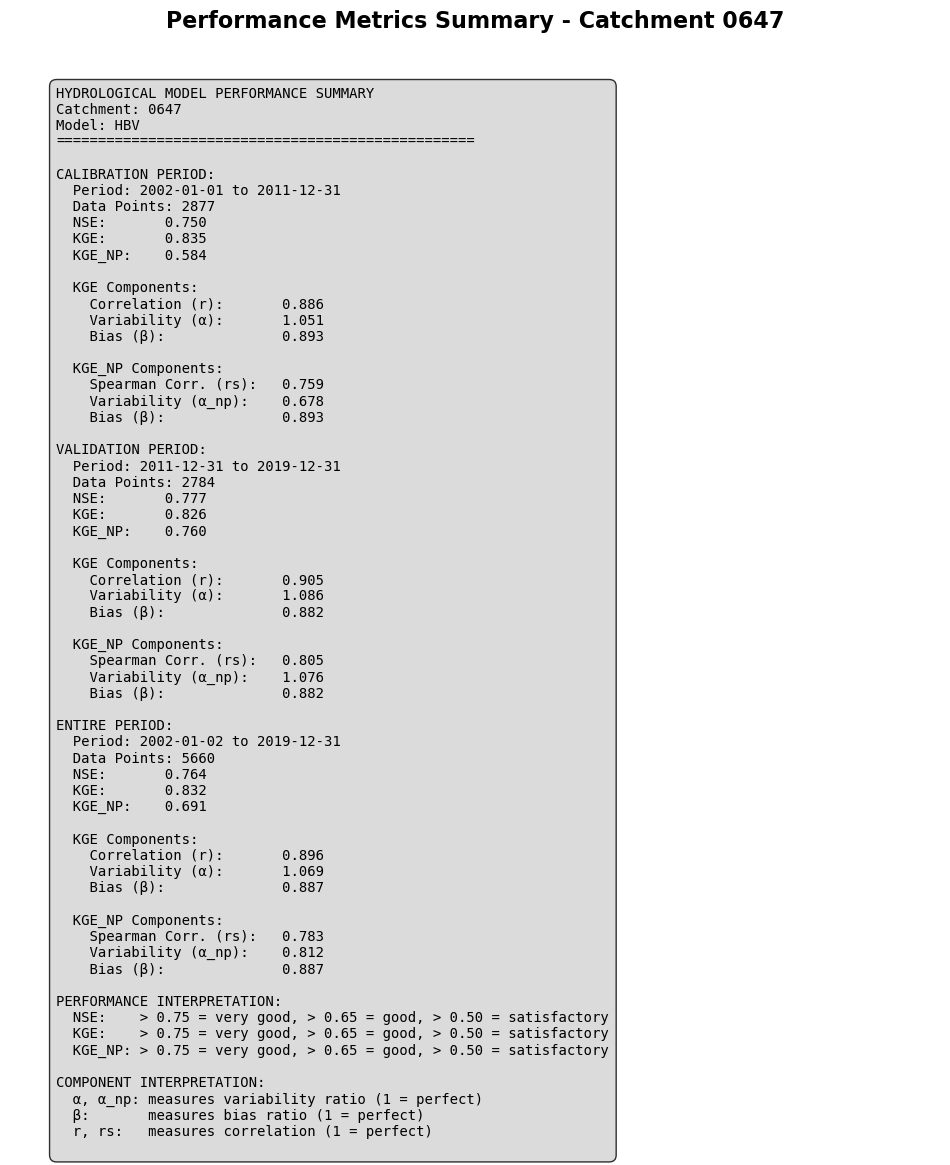

   ✓ Performance metrics calculated
   Validation NSE: 0.777
   Validation KGE: 0.826


In [12]:
# Cell 5: Performance Metrics
print("\n2. Performance metrics summary...")
metrics_result = plot_performance_metrics_summary(config, plot_dirs)

if metrics_result:
    print("   ✓ Performance metrics calculated")
    if 'validation' in metrics_result:
        print(f"   Validation NSE: {metrics_result['validation']['NSE']:.3f}")
        print(f"   Validation KGE: {metrics_result['validation']['KGE']:.3f}")


3. Hydrological regime plot...
Loading hydrograph data:
  - File: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/HBV/output/0647_HBV_Hydrographs.csv
  - Found columns: sim=0647 [m3/s], obs=0647 (observed) [m3/s], precip=precip [mm/day]
  - Data range: 2002-01-02 00:00:00 to 2019-12-31 00:00:00
Saved hydrological regime plot to: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/HBV/output/plots/hydrographs/hydrological_regime_0647.png


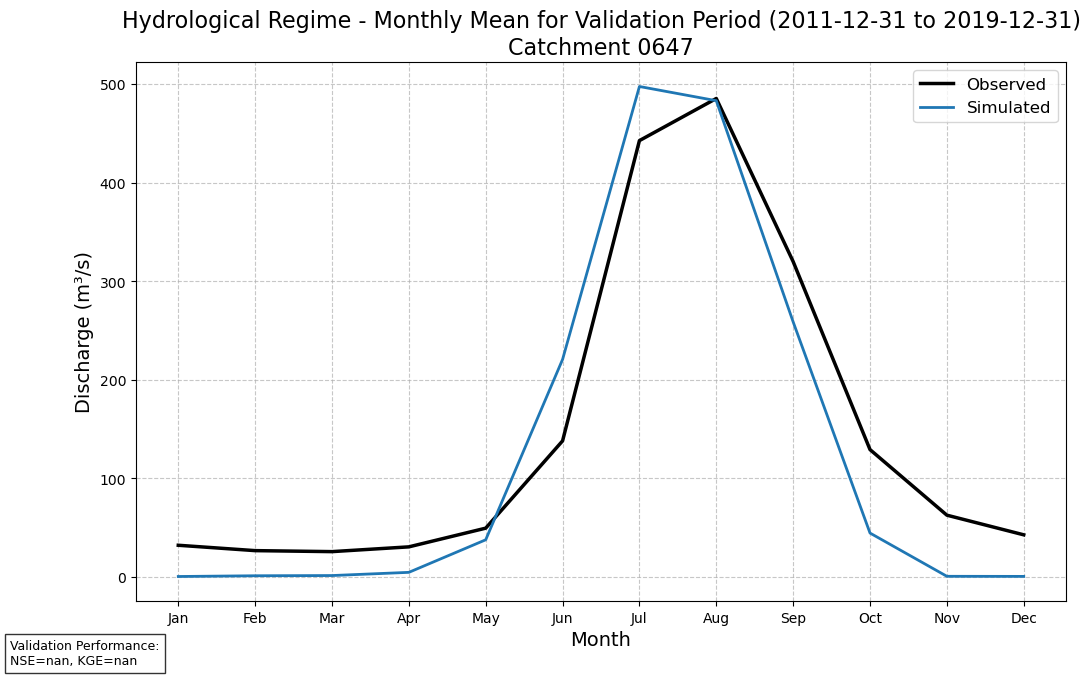

,sim_Q,obs_Q
month,,
1,0.382681,32.083663
2,1.134123,26.629327
3,1.351619,25.620565
4,4.591378,30.455417
5,37.625238,49.428629
6,220.613994,137.985000
7,497.527008,442.629032
8,483.129056,485.366935
9,258.714620,319.895833


In [8]:
# Cell 6: Hydrological Regime
print("\n3. Hydrological regime plot...")
plot_hydrological_regime(config, plot_dirs)



4. Hydrograph time series plots...
Loading hydrograph data:
  - File: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/HBV/output/0647_HBV_Hydrographs.csv
  - Found columns: sim=0647 [m3/s], obs=0647 (observed) [m3/s], precip=precip [mm/day]
  - Data range: 2002-01-02 00:00:00 to 2019-12-31 00:00:00
Saved split hydrograph time series plot to: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/HBV/output/plots/hydrographs/hydrograph_timeseries_split_0647.png


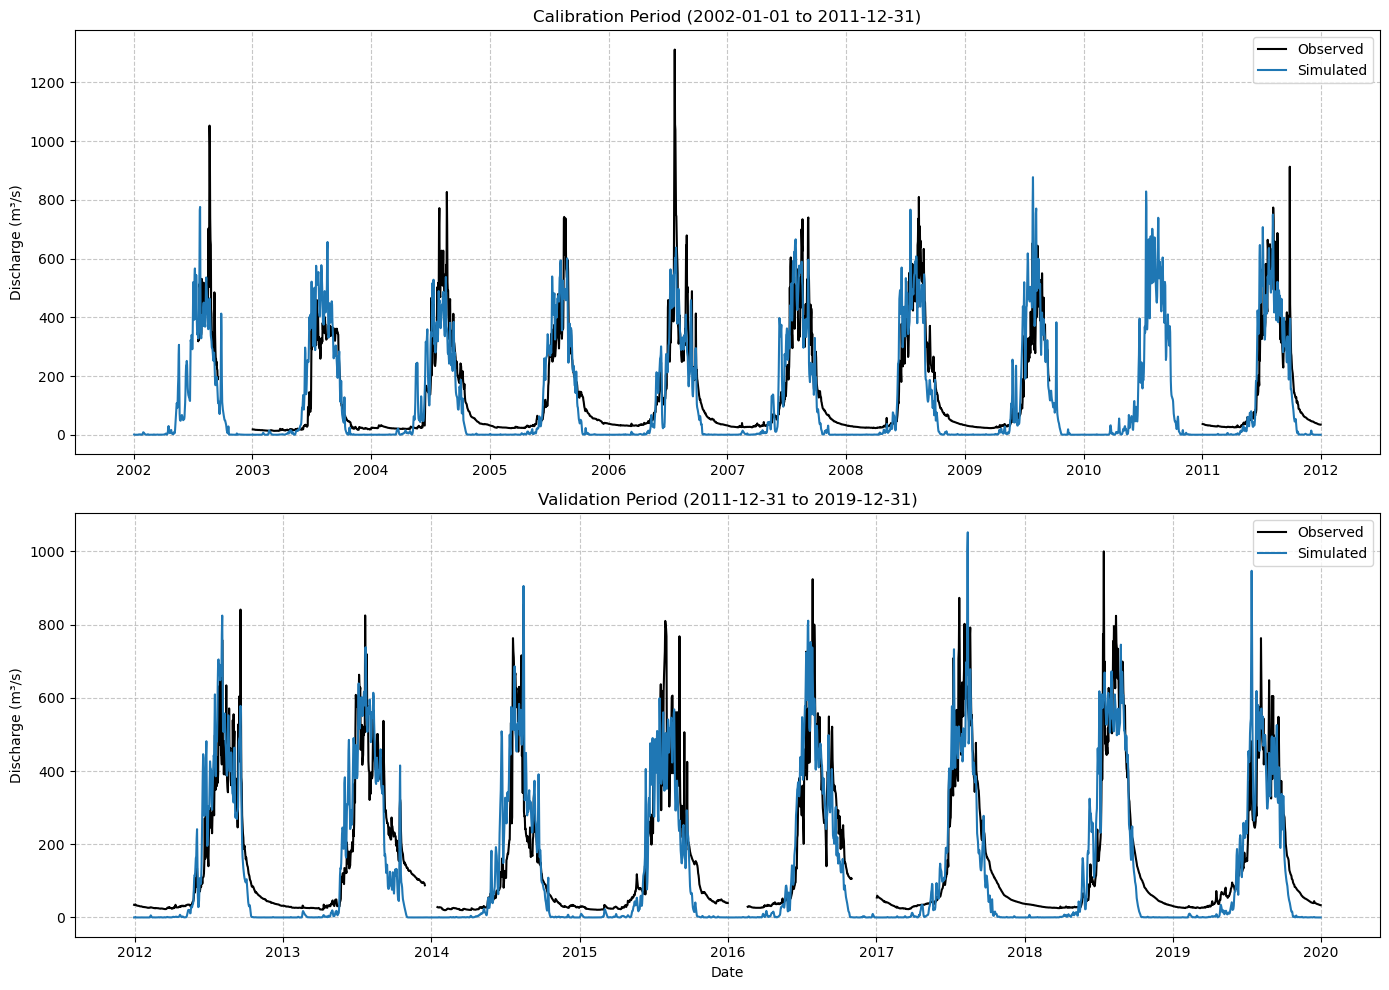

Saved hydrograph for random year plot to: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/HBV/output/plots/hydrographs/hydrograph_random_year_2017_0647.png


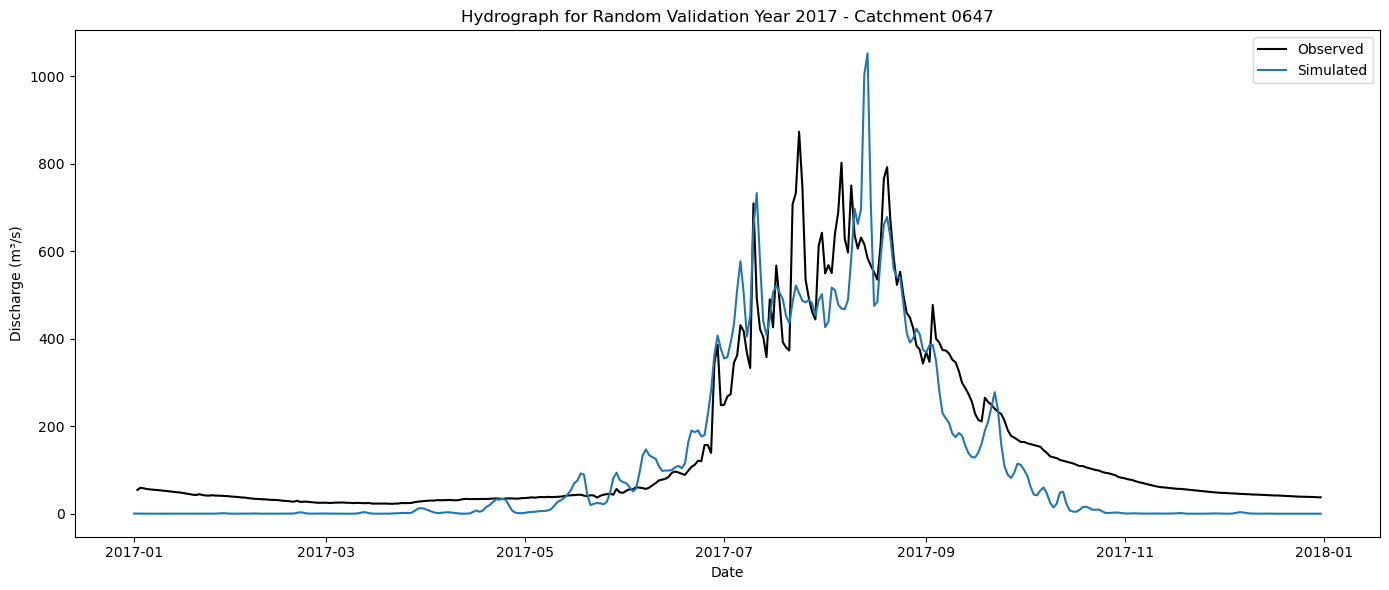

   ✓ Time series plots created


In [7]:
# Cell 7: Hydrograph Time Series
print("\n4. Hydrograph time series plots...")
plot_hydrograph_timeseries(config, plot_dirs)
print("   ✓ Time series plots created")

In [4]:
# Cell 8: Test SWE Functions
print("\n" + "=" * 60)
print("TESTING SWE FUNCTIONS")
print("=" * 60)

# Test 1: Load SWE data
print("\n1. Loading SWE data...")
sim_data, area_data = load_swe_data(config)

if sim_data is not None:
    print(f"   ✓ Loaded SWE data: {len(sim_data)} records")
else:
    print("   ✗ Failed to load SWE data")


TESTING SWE FUNCTIONS

1. Loading SWE data...
Loading SWE data:
  - Simulated data: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/HBV/output/0647_HBV_SNOW_Daily_Average_ByHRUGroup.csv
  - First line starts with: ,HRUGroup:,AllHRUs,800-900m,900-1000m,1000-1100m,1100-1200m,1200-1300m,1300-1400m,1400-1500m,1500-1600m,1600-1700m,1700-1800m,1800-1900m,1900-2000m,2000-2100m,2100-2200m,2200-2300m,2300-2400m,2400-250
  - Second line starts with: time,day,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,m
  - Loaded data shape: (6573, 68)
  - Columns after loading: ['Unnamed: 0', 'HRUGroup:', 'AllHRUs', '800-900m', '900-1000m', '1000-1100m', '1100-1200m', '1200-1300m', '1300-1400m', '1400-1500m']...
  - Created date range starting from config start_date: 2002-01-01 00:00:00
  - Successfully loaded simulated SWE data
  - Date range: 2002-01-01 00:00:00 to 2019-12-30 00:00:00
  - Final columns: ['AllHRUs', '800-900m', '900-10


2. Area-weighted SWE time series...
Loading SWE data:
  - Simulated data: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/HBV/output/0647_HBV_SNOW_Daily_Average_ByHRUGroup.csv
  - First line starts with: ,HRUGroup:,AllHRUs,800-900m,900-1000m,1000-1100m,1100-1200m,1200-1300m,1300-1400m,1400-1500m,1500-1600m,1600-1700m,1700-1800m,1800-1900m,1900-2000m,2000-2100m,2100-2200m,2200-2300m,2300-2400m,2400-250
  - Second line starts with: time,day,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,m
  - Loaded data shape: (6573, 68)
  - Columns after loading: ['Unnamed: 0', 'HRUGroup:', 'AllHRUs', '800-900m', '900-1000m', '1000-1100m', '1100-1200m', '1200-1300m', '1300-1400m', '1400-1500m']...
  - Created date range starting from config start_date: 2002-01-01 00:00:00
  - Successfully loaded simulated SWE data
  - Date range: 2002-01-01 00:00:00 to 2019-12-30 00:00:00
  - Final columns: ['AllHRUs', '800-900m', '900-1000m', '100

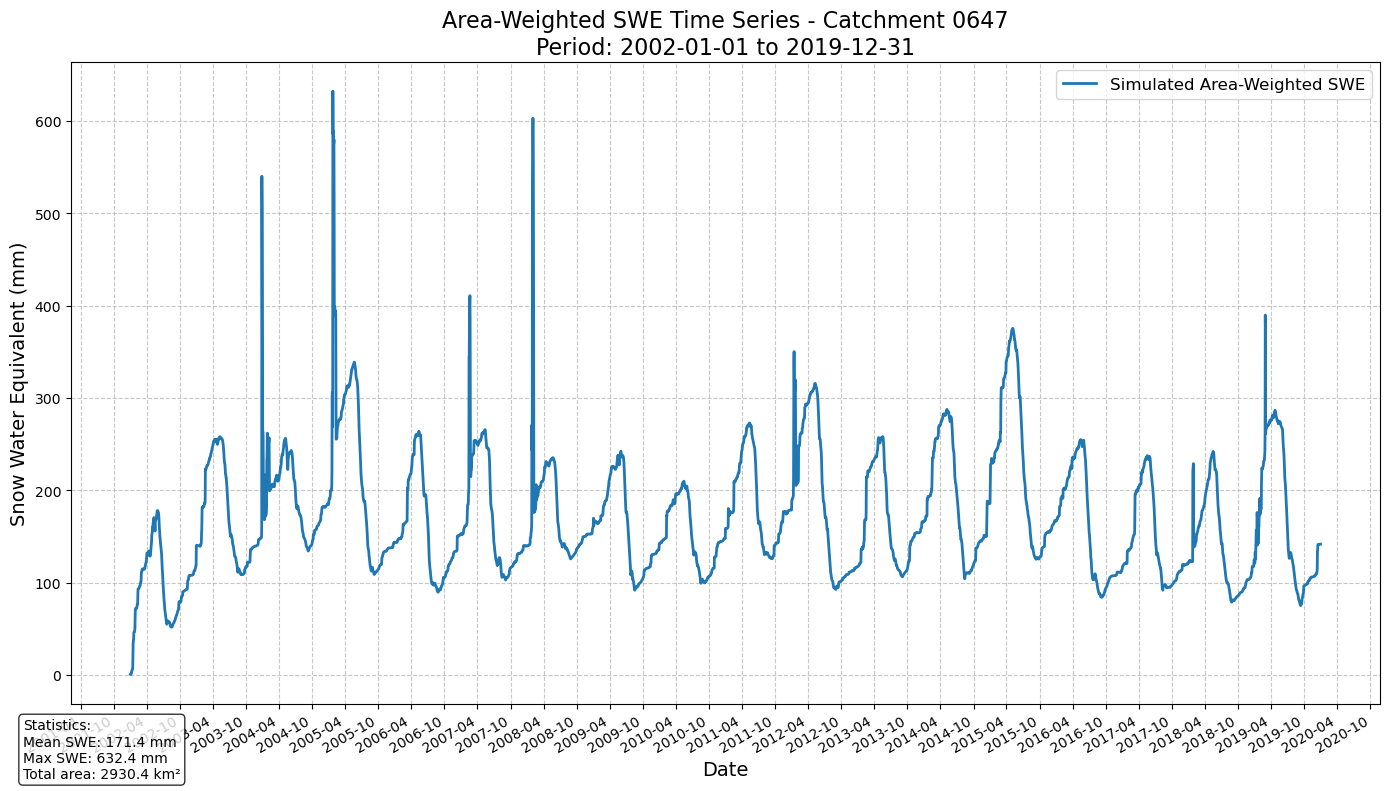


SWE Analysis Results for Catchment 0647:
  Mean SWE: 171.36 mm
  Max SWE: 632.36 mm
  Total catchment area: 2930.40 km²
   ✓ SWE time series plot created


In [5]:
# Cell 9: Area-Weighted SWE Time Series
print("\n2. Area-weighted SWE time series...")
swe_ts_result = plot_area_weighted_swe_timeseries(config, plot_dirs)

if swe_ts_result is not None:
    print("   ✓ SWE time series plot created")

In [ ]:
# Cell 10: SWE by Elevation
print("\n3. SWE by elevation bands...")
swe_elev_result = plot_swe_time_series_by_elevation(config, plot_dirs)

if swe_elev_result is not None:
    print("   ✓ SWE elevation plot created")


3. SWE by elevation bands...
Loading SWE data by elevation bands:
  - Period: 1995-12-31 to 2010-12-31
  - Loaded data shape: (11322, 67)
  - Columns: ['Unnamed: 0', 'HRUGroup:', 'AllHRUs', '1400-1500m', '1500-1600m', '1600-1700m', '1700-1800m', '1800-1900m', '1900-2000m', '2000-2100m']...
  - Date column: 'Unnamed: 0'
  - Warning: Dates parsed as 1970, trying alternative method...


/home/jberg/Raven-world/src/postprocessing_single.py:759: DtypeWarning: Columns (0,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(sim_file)


  - Creating date range from config dates...
  - Date range: 1980-01-01 00:00:00 to 2010-12-30 00:00:00
  - Found 63 elevation bands: ['1400-1500m', '1500-1600m', '1600-1700m', '1700-1800m', '1800-1900m']...
  - Filtered to 5479 records
✓ Saved SWE elevation band plot to: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0102/HBV/output/plots/swe/swe_time_series_by_elevation_0102.png



4. Peak SWE analysis...
Loading SWE data:
  - Simulated data: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/HBV/output/0647_HBV_SNOW_Daily_Average_ByHRUGroup.csv
  - First line starts with: ,HRUGroup:,AllHRUs,800-900m,900-1000m,1000-1100m,1100-1200m,1200-1300m,1300-1400m,1400-1500m,1500-1600m,1600-1700m,1700-1800m,1800-1900m,1900-2000m,2000-2100m,2100-2200m,2200-2300m,2300-2400m,2400-250
  - Second line starts with: time,day,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,m
  - Loaded data shape: (6573, 68)
  - Columns after loading: ['Unnamed: 0', 'HRUGroup:', 'AllHRUs', '800-900m', '900-1000m', '1000-1100m', '1100-1200m', '1200-1300m', '1300-1400m', '1400-1500m']...
  - Created date range starting from config start_date: 2002-01-01 00:00:00
  - Successfully loaded simulated SWE data
  - Date range: 2002-01-01 00:00:00 to 2019-12-30 00:00:00
  - Final columns: ['AllHRUs', '800-900m', '900-1000m', '1000-1100m', '1

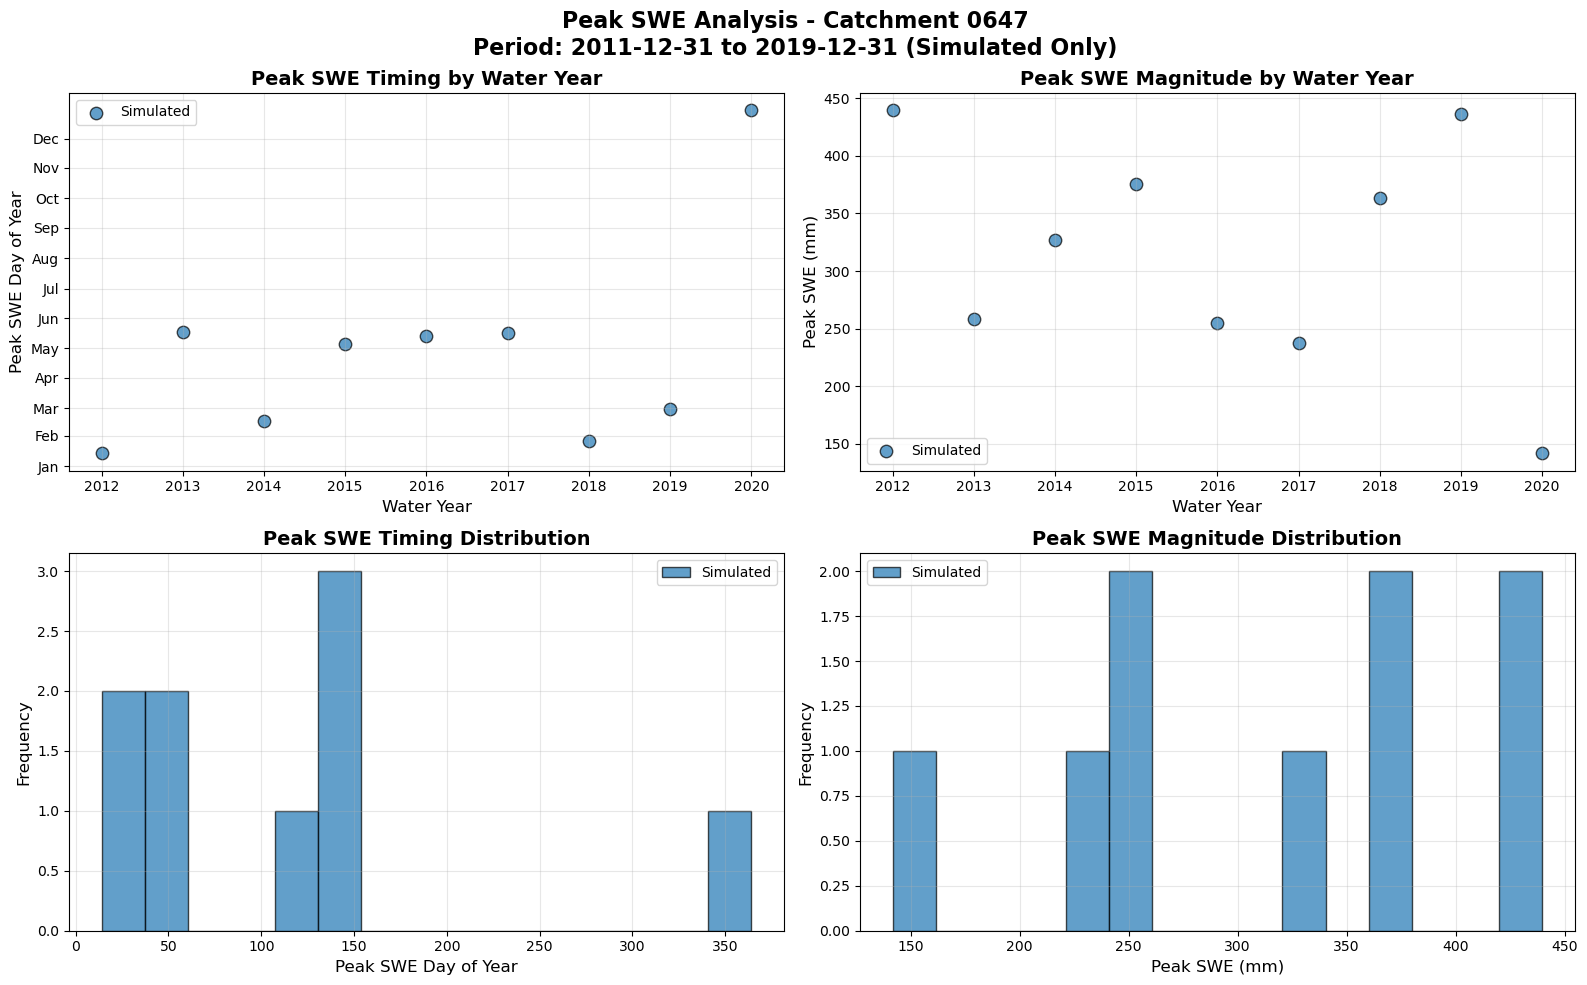


Peak SWE Analysis Summary for Catchment 0647:
  Period: 2011-12-31 to 2019-12-31

  Simulated Peak SWE:
    Number of water years: 9
    Mean peak timing: DOY 116.2 ± 99.5
    Median peak timing: DOY 126.0
    Mean peak SWE: 314.9 ± 93.9 mm
    Median peak SWE: 326.8 mm
    Earliest peak: DOY 14 (Jan 14)
    Latest peak: DOY 364 (Dec 30)
   ✓ Peak SWE analysis completed
   Water years analyzed: 9


In [4]:
# Cell 11: Peak SWE Analysis
print("\n4. Peak SWE analysis...")
peak_result = analyze_peak_swe(config, plot_dirs)

if peak_result is not None:
    print("   ✓ Peak SWE analysis completed")
    print(f"   Water years analyzed: {len(peak_result.get('simulated', {}))}")


5. Spatial SWE distribution...
Creating spatial SWE peak plots for catchment 0647:
  - Period: 2011-12-31 to 2019-12-31
  - Simulated data only (no observations)
  - Excluding glacier areas (Landuse_Cl 7 and 8)
  - Excluding HRUs with SWE > 1000mm
  - Loaded 592 HRUs from shapefile
  - Filtered to 280 non-glacier HRUs
  - Loaded simulated SWE data: 2922 records
  - Found 280 matching non-glacier HRU columns
  - Example years: [2010, 2015]

  Processing year 2010...

  Processing year 2015...
    Simulated peak: 2015-05-06 (333.3 mm)
    Creating plot for simulated peak date...
    Saved simulated peak plot to: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/HBV/output/plots/swe/spatial_swe_sim_peak_WY2015_0647.png


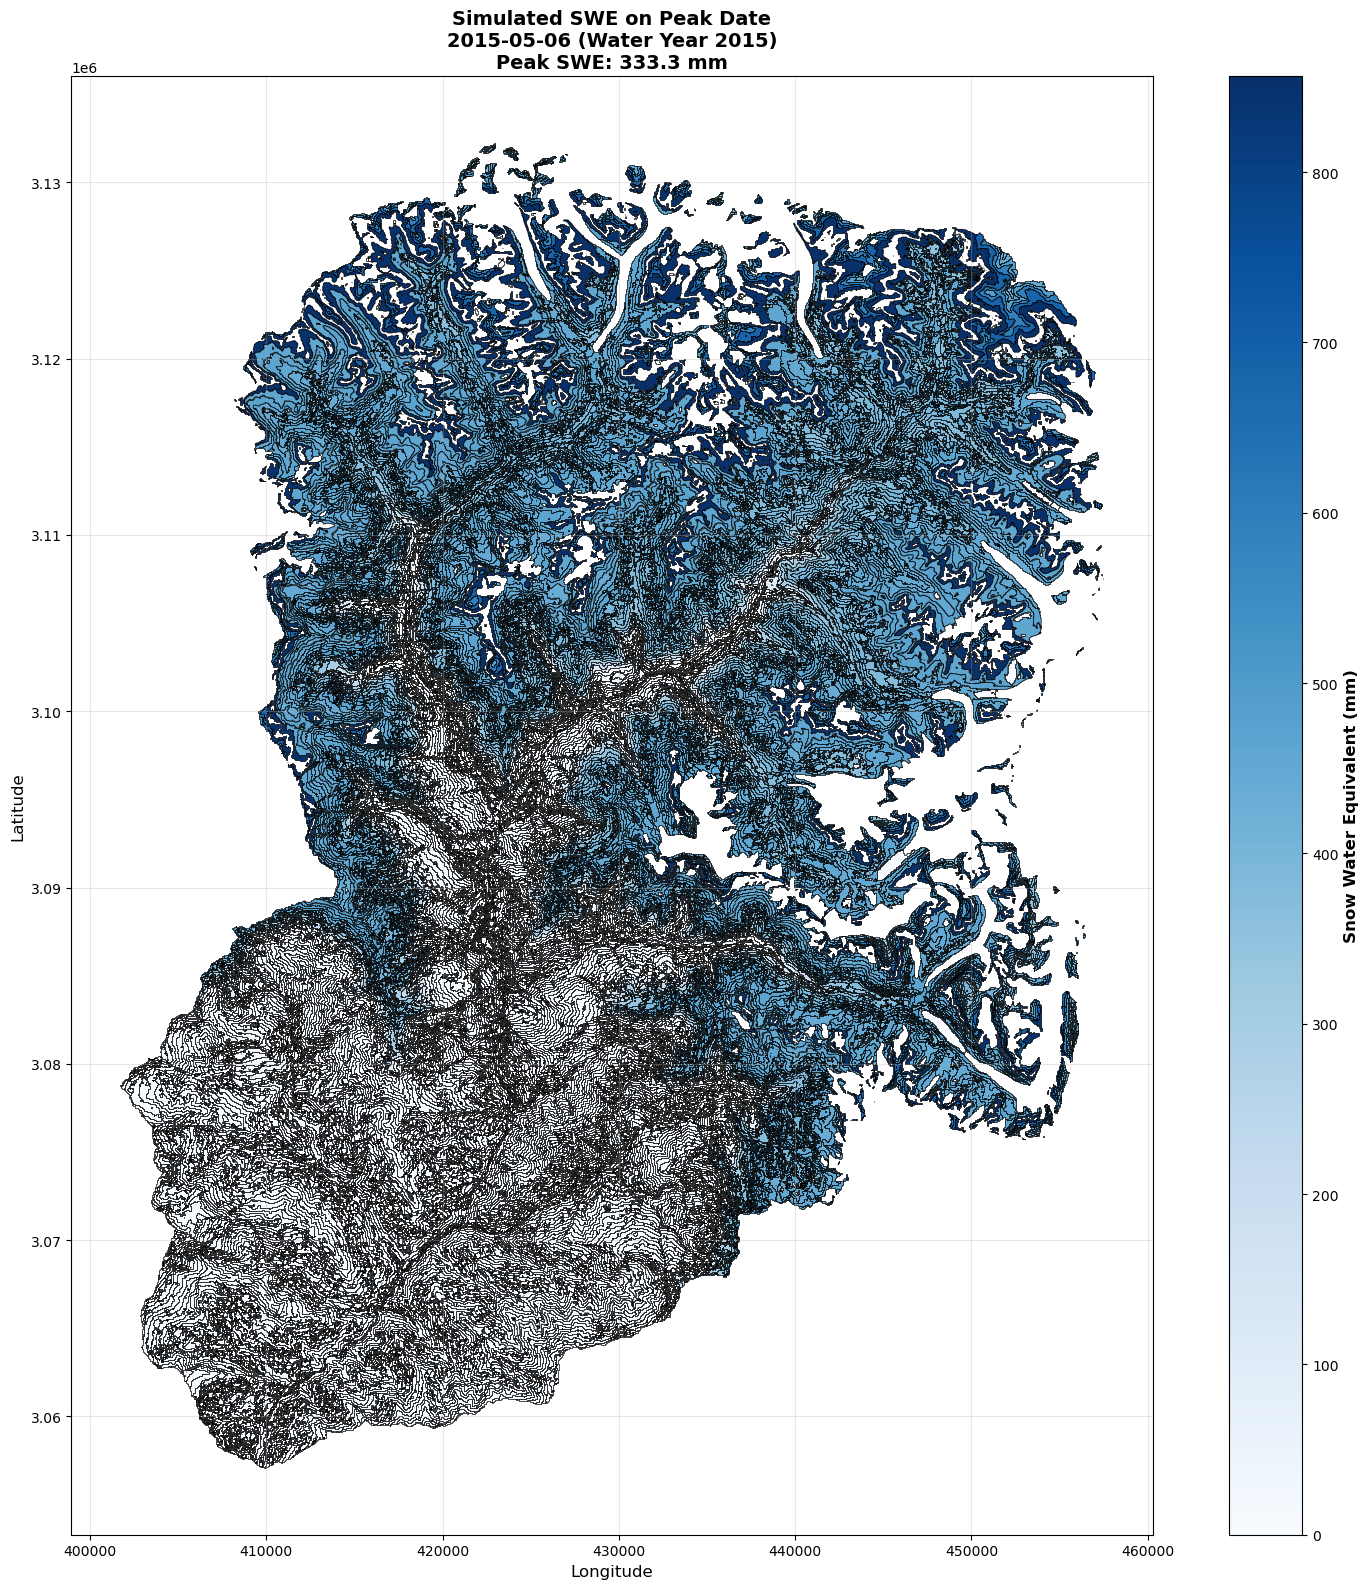


Spatial SWE Peak Analysis Summary:
  Catchment: 0647
  Validation period: 2011-12-31 to 2019-12-31
  Example years processed: [2015]
  Original HRUs in shapefile: 592
  Non-glacier HRUs: 280
  HRUs with SWE data: 280

  Water Year 2015:
    Simulated peak: 2015-05-06 (333.3 mm)
   ✓ Spatial SWE plots created


In [4]:
# Cell 12: Spatial SWE Distribution
print("\n5. Spatial SWE distribution...")
spatial_result = plot_spatial_swe_distribution(config, plot_dirs, example_years=[2010, 2015])

if spatial_result is not None:
    print("   ✓ Spatial SWE plots created")

In [5]:
# Cell 13: Test Parameter Functions
print("\n" + "=" * 60)
print("TESTING PARAMETER FUNCTIONS")
print("=" * 60)

print("\n1. Loading parameter values...")
param_data = load_parameter_values(config, top_n=100)

if param_data:
    print(f"   ✓ Loaded {param_data['n_sets']} parameter sets")
    print(f"   Parameters: {len(param_data['parameters'])} found")


TESTING PARAMETER FUNCTIONS

1. Loading parameter values...

----------------------------------------
Analyzing parameters for 0647
----------------------------------------
Found calibration file: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/HBV/output/calibration_results_0647_HBV_20251202_210044.csv
Loaded 251 parameter sets
Using 'objective' column for parameter selection
Using objective column: objective
Selected top 100 parameter sets
Objective range: 0.8182 to 0.8466
Found 18 parameter columns: HBV_RainSnow_Temp, HBV_Melt_Factor, HBV_Refreeze_Factor, HBV_Snow_SWI, HBV_Porosity...
   ✓ Loaded 100 parameter sets
   Parameters: 18 found



2. Parameter distribution plots...

----------------------------------------
Analyzing parameters for 0647
----------------------------------------
Found calibration file: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/HBV/output/calibration_results_0647_HBV_20251202_210044.csv
Loaded 251 parameter sets
Using 'objective' column for parameter selection
Using objective column: objective
Selected top 100 parameter sets
Objective range: 0.8182 to 0.8466
Found 18 parameter columns: HBV_RainSnow_Temp, HBV_Melt_Factor, HBV_Refreeze_Factor, HBV_Snow_SWI, HBV_Porosity...
Creating 4x5 subplot layout for 18 parameters


Saved parameter boxplots to: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/HBV/output/plots/parameters/parameter_boxplots_0647.png


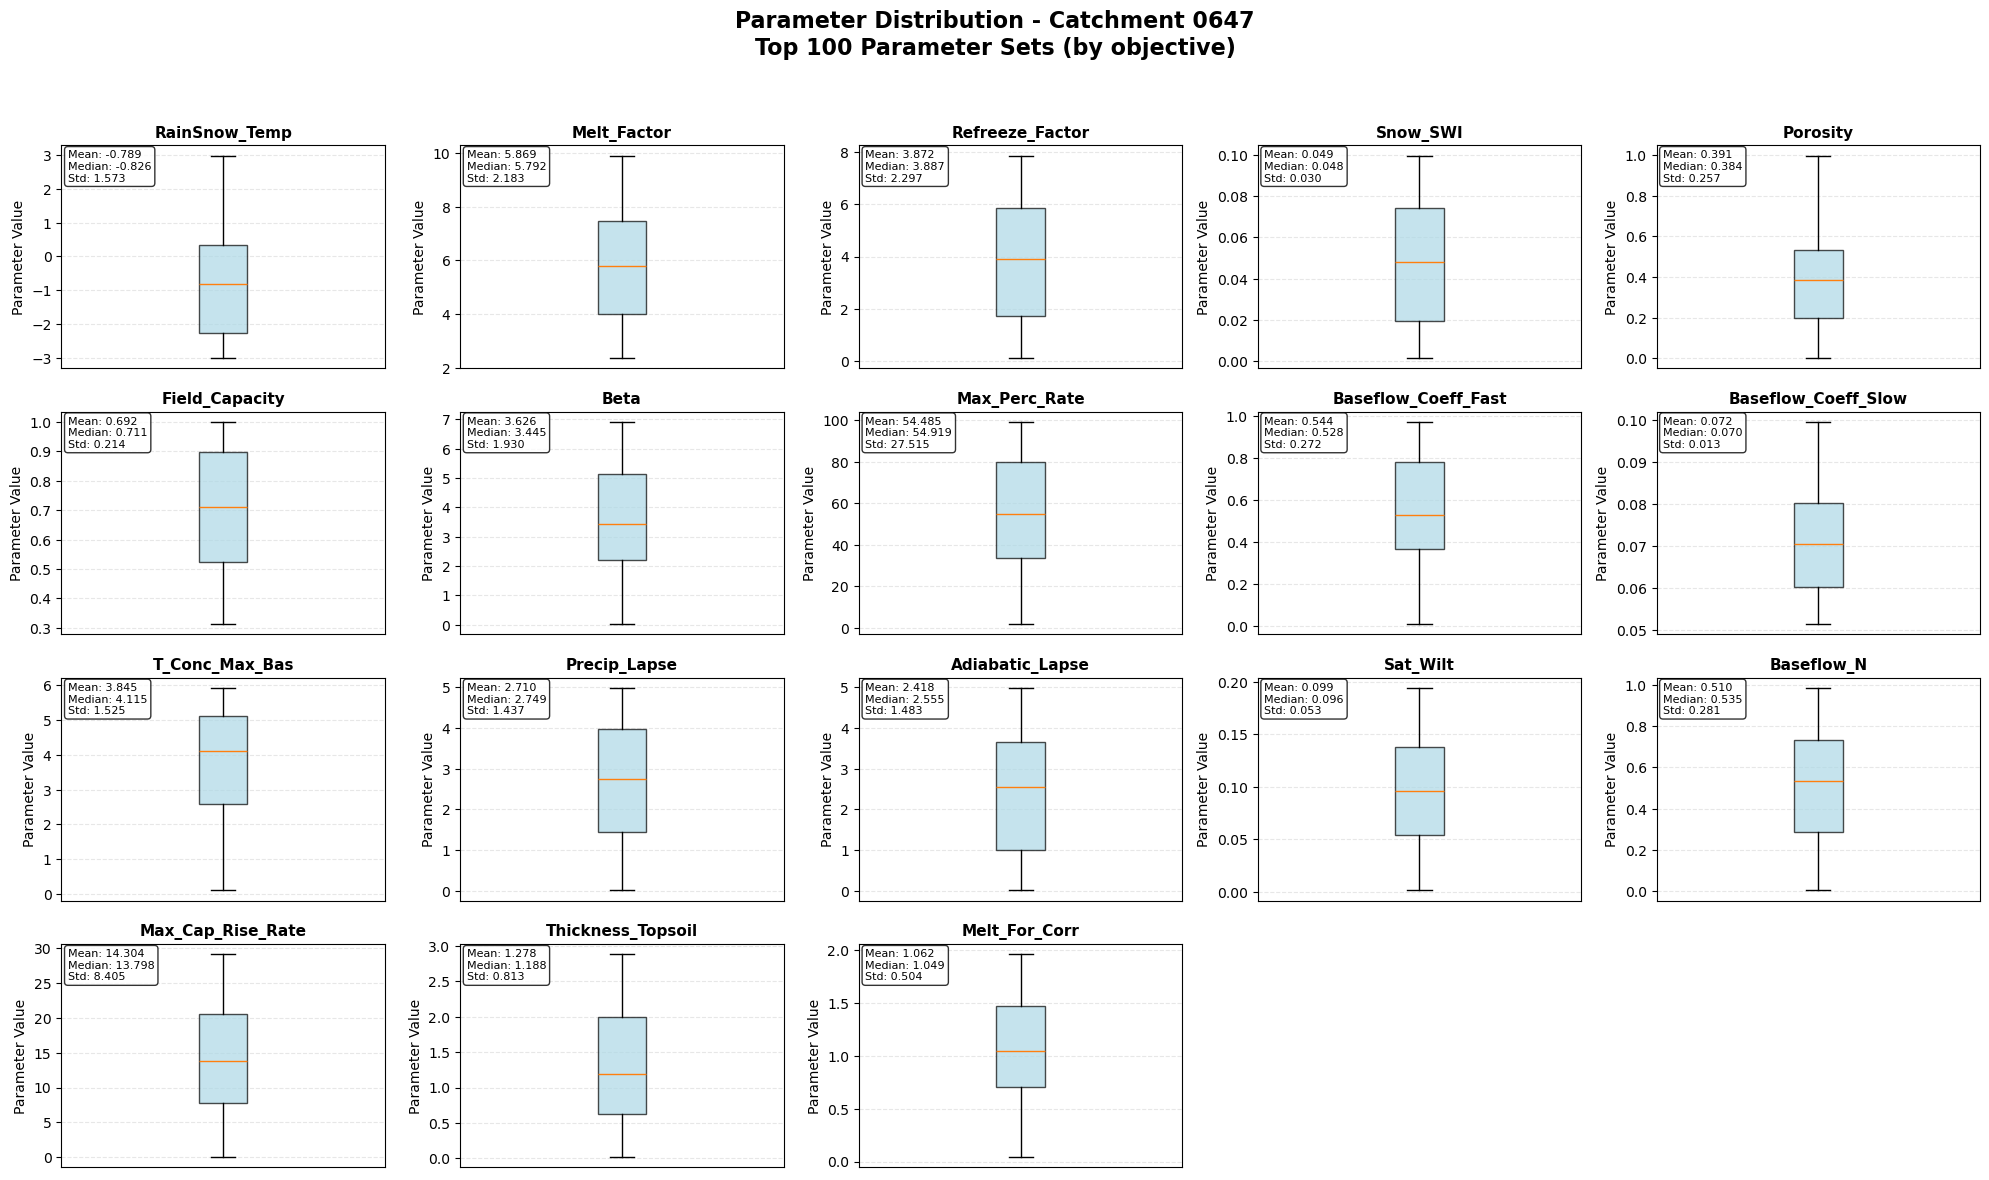


Parameter Analysis Summary for Catchment 0647:
  Number of parameters: 18
  Number of parameter sets: 100
  Objective function: objective

Parameter Ranges:
  RainSnow_Temp  : -2.998 - 2.981 (mean: -0.789)
  Melt_Factor    : 2.373 - 9.900 (mean: 5.869)
  Refreeze_Factor: 0.104 - 7.879 (mean: 3.872)
  Snow_SWI       : 0.002 - 0.100 (mean: 0.049)
  Porosity       : 0.001 - 0.998 (mean: 0.391)
  Field_Capacity : 0.313 - 0.999 (mean: 0.692)
  Beta           : 0.017 - 6.911 (mean: 3.626)
  Max_Perc_Rate  : 1.774 - 99.084 (mean: 54.485)
  Baseflow_Coeff_Fast: 0.010 - 0.972 (mean: 0.544)
  Baseflow_Coeff_Slow: 0.051 - 0.099 (mean: 0.072)
  T_Conc_Max_Bas : 0.094 - 5.922 (mean: 3.845)
  Precip_Lapse   : 0.004 - 4.982 (mean: 2.710)
  Adiabatic_Lapse: 0.014 - 4.970 (mean: 2.418)
  Sat_Wilt       : 0.001 - 0.194 (mean: 0.099)
  Baseflow_N     : 0.002 - 0.985 (mean: 0.510)
  Max_Cap_Rise_Rate: 0.089 - 29.041 (mean: 14.304)
  Thickness_Topsoil: 0.024 - 2.875 (mean: 1.278)
  Melt_For_Corr  : 0.045 

In [6]:
# Cell 14: Parameter Boxplots
print("\n2. Parameter distribution plots...")
param_plot = plot_parameter_boxplots(config, plot_dirs, top_n=100)

if param_plot is not None:
    print("   ✓ Parameter boxplots created")

In [7]:
# Cell 15: Test Storage Functions
print("\n" + "=" * 60)
print("TESTING STORAGE FUNCTIONS")
print("=" * 60)

print("\n1. Loading storage data...")
storage_data = load_storage_data(config)

if storage_data is not None:
    print(f"   ✓ Loaded {len(storage_data)} records")
    print(f"   Storage components: {[c for c in storage_data.columns if c not in ['date', 'month', 'year']]}")


TESTING STORAGE FUNCTIONS

1. Loading storage data...
Loading storage data:
  - File: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/HBV/output/0647_HBV_WatershedStorage.csv
  - Loaded 6573 records from 2002-01-02 00:00:00 to 2019-12-31 00:00:00
  - Storage columns: ['rainfall [mm/day]', 'snowfall [mm/d SWE]', 'Rivulet Storage [mm]', 'Cum. Losses to Atmosphere [mm]', 'Ponded Water [mm]', 'Soil Water[0] [mm]', 'Soil Water[1] [mm]', 'Soil Water[2] [mm]', 'Snow Melt (Liquid) [mm]', 'Snow [mm]', ' Total [mm]', ' Cum. Inputs [mm]', ' Cum. Outflow [mm]', ' MB Error [mm]']
   ✓ Loaded 6573 records
   Storage components: ['rainfall [mm/day]', 'snowfall [mm/d SWE]', 'Rivulet Storage [mm]', 'Cum. Losses to Atmosphere [mm]', 'Ponded Water [mm]', 'Soil Water[0] [mm]', 'Soil Water[1] [mm]', 'Soil Water[2] [mm]', 'Snow Melt (Liquid) [mm]', 'Snow [mm]', ' Total [mm]', ' Cum. Inputs [mm]', ' Cum. Outflow [mm]', ' MB Error [mm]']



2. Storage time series plot...
Loading storage data:
  - File: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/HBV/output/0647_HBV_WatershedStorage.csv
  - Loaded 6573 records from 2002-01-02 00:00:00 to 2019-12-31 00:00:00
  - Storage columns: ['rainfall [mm/day]', 'snowfall [mm/d SWE]', 'Rivulet Storage [mm]', 'Cum. Losses to Atmosphere [mm]', 'Ponded Water [mm]', 'Soil Water[0] [mm]', 'Soil Water[1] [mm]', 'Soil Water[2] [mm]', 'Snow Melt (Liquid) [mm]', 'Snow [mm]', ' Total [mm]', ' Cum. Inputs [mm]', ' Cum. Outflow [mm]', ' MB Error [mm]']
Saved storage plot to: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/HBV/output/plots/storage/storage_timeseries_0647.png


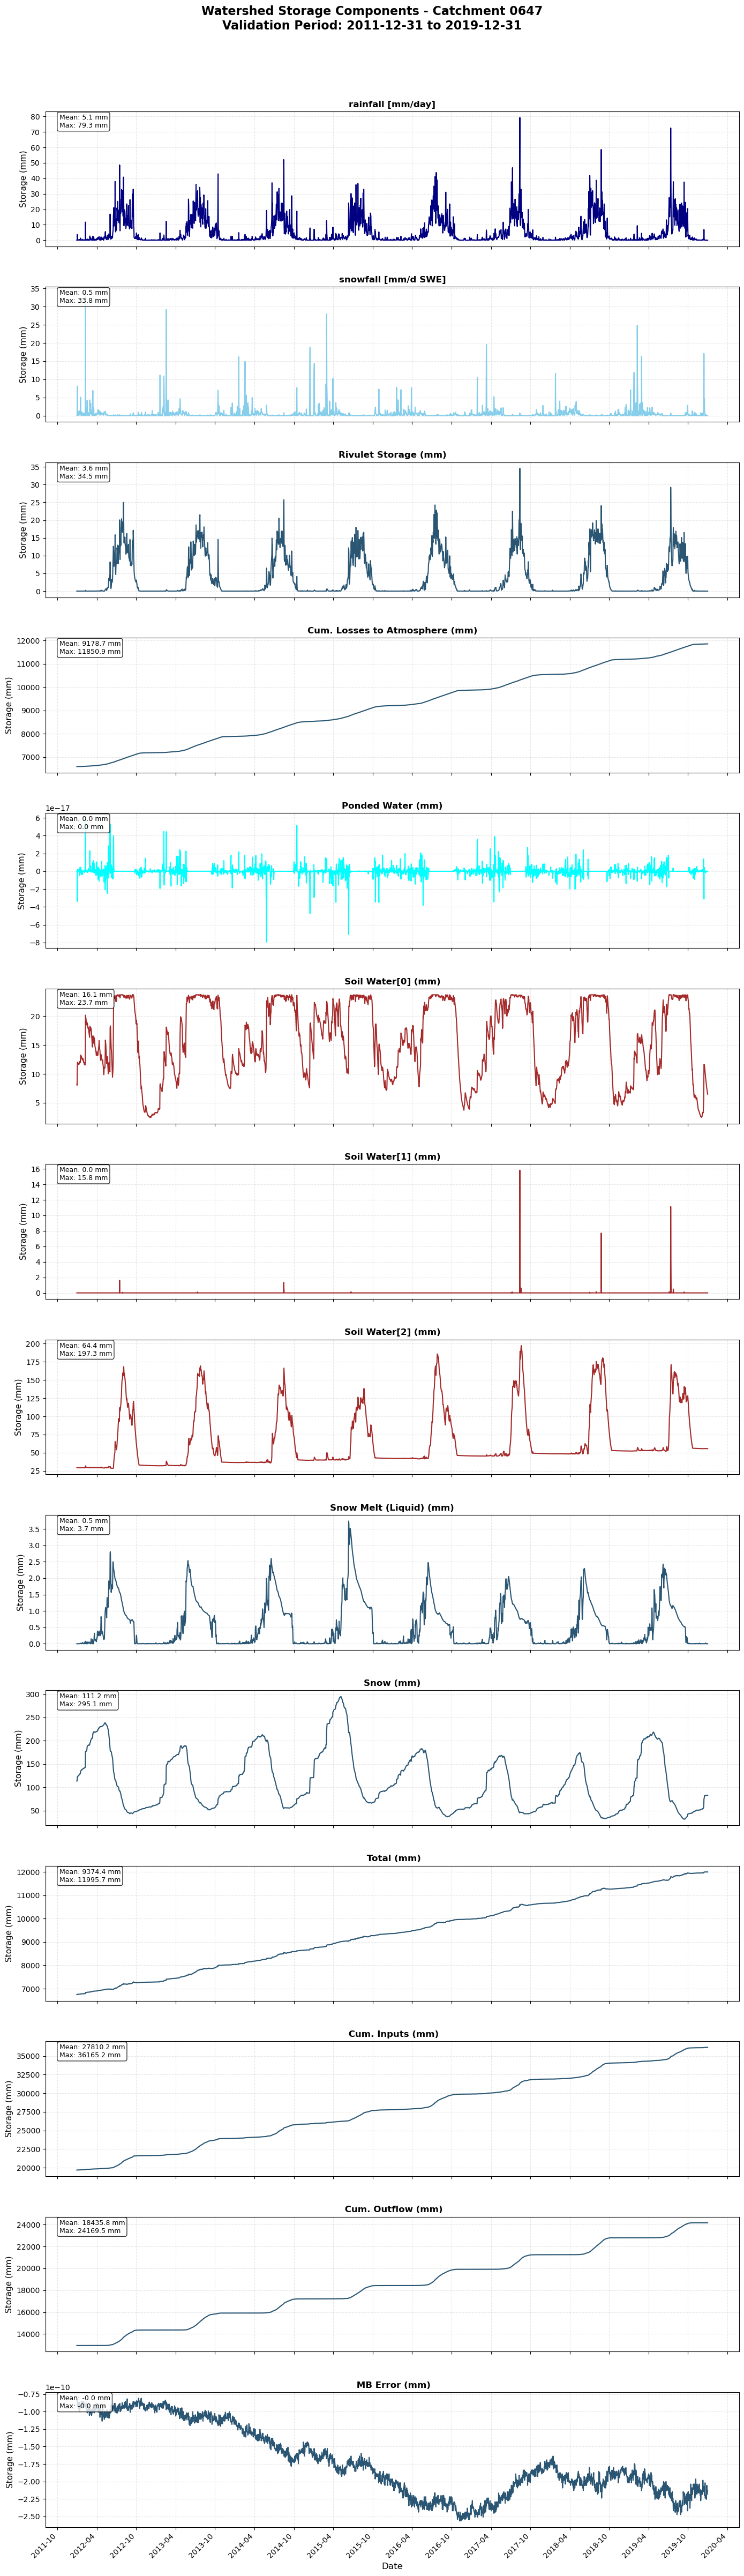


Storage Analysis Summary for Catchment 0647:
  Period: 2011-12-31 to 2019-12-31
  Number of storage components: 14
  Storage components:
    rainfall [mm/day]: Mean=5.1 mm, Max=79.3 mm
    snowfall [mm/d SWE]: Mean=0.5 mm, Max=33.8 mm
    Rivulet Storage [mm]: Mean=3.6 mm, Max=34.5 mm
    Cum. Losses to Atmosphere [mm]: Mean=9178.7 mm, Max=11850.9 mm
    Ponded Water [mm]: Mean=0.0 mm, Max=0.0 mm
    Soil Water[0] [mm]: Mean=16.1 mm, Max=23.7 mm
    Soil Water[1] [mm]: Mean=0.0 mm, Max=15.8 mm
    Soil Water[2] [mm]: Mean=64.4 mm, Max=197.3 mm
    Snow Melt (Liquid) [mm]: Mean=0.5 mm, Max=3.7 mm
    Snow [mm]: Mean=111.2 mm, Max=295.1 mm
     Total [mm]: Mean=9374.4 mm, Max=11995.7 mm
     Cum. Inputs [mm]: Mean=27810.2 mm, Max=36165.2 mm
     Cum. Outflow [mm]: Mean=18435.8 mm, Max=24169.5 mm
     MB Error [mm]: Mean=-0.0 mm, Max=-0.0 mm
   ✓ Storage time series plot created


In [8]:
# Cell 16: Storage Time Series
print("\n2. Storage time series plot...")
storage_plot = plot_storage_timeseries(config, plot_dirs)

if storage_plot is not None:
    print("   ✓ Storage time series plot created")


TESTING CONTRIBUTIONS FUNCTIONS

1. Loading GloGEM data...
Loading catchment-averaged GloGEM data for catchment 0647:
  - File: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/topo_files/GloGEM_catchment_averaged.csv
  - Period: 2002-01-01 to 2019-12-31
  - Loaded 6570 records
  - Columns: ['date', 'icemelt_glacier_area', 'icemelt_catchment_area', 'snowmelt_glacier_area', 'snowmelt_catchment_area', 'rain_glacier_area', 'rain_catchment_area', 'melt_glacier_area', 'melt_catchment_area']
  ✓ Successfully loaded catchment-averaged GloGEM data
  - Date range: 2002-01-01 00:00:00 to 2019-12-31 00:00:00

  Mean values (glacier area):
    Ice melt: 0.277 mm/day
    Snow melt: 0.129 mm/day
    Rainfall: 0.184 mm/day
    Total melt: 0.590 mm/day

  Mean values (catchment area):
    Ice melt: 0.277 mm/day
    Snow melt: 0.129 mm/day
    Rainfall: 0.184 mm/day
    Total melt: 0.590 mm/day
   ✓ Loaded GloGEM data: 6570 records

2. GloGEM regime plot...
Loading catchment

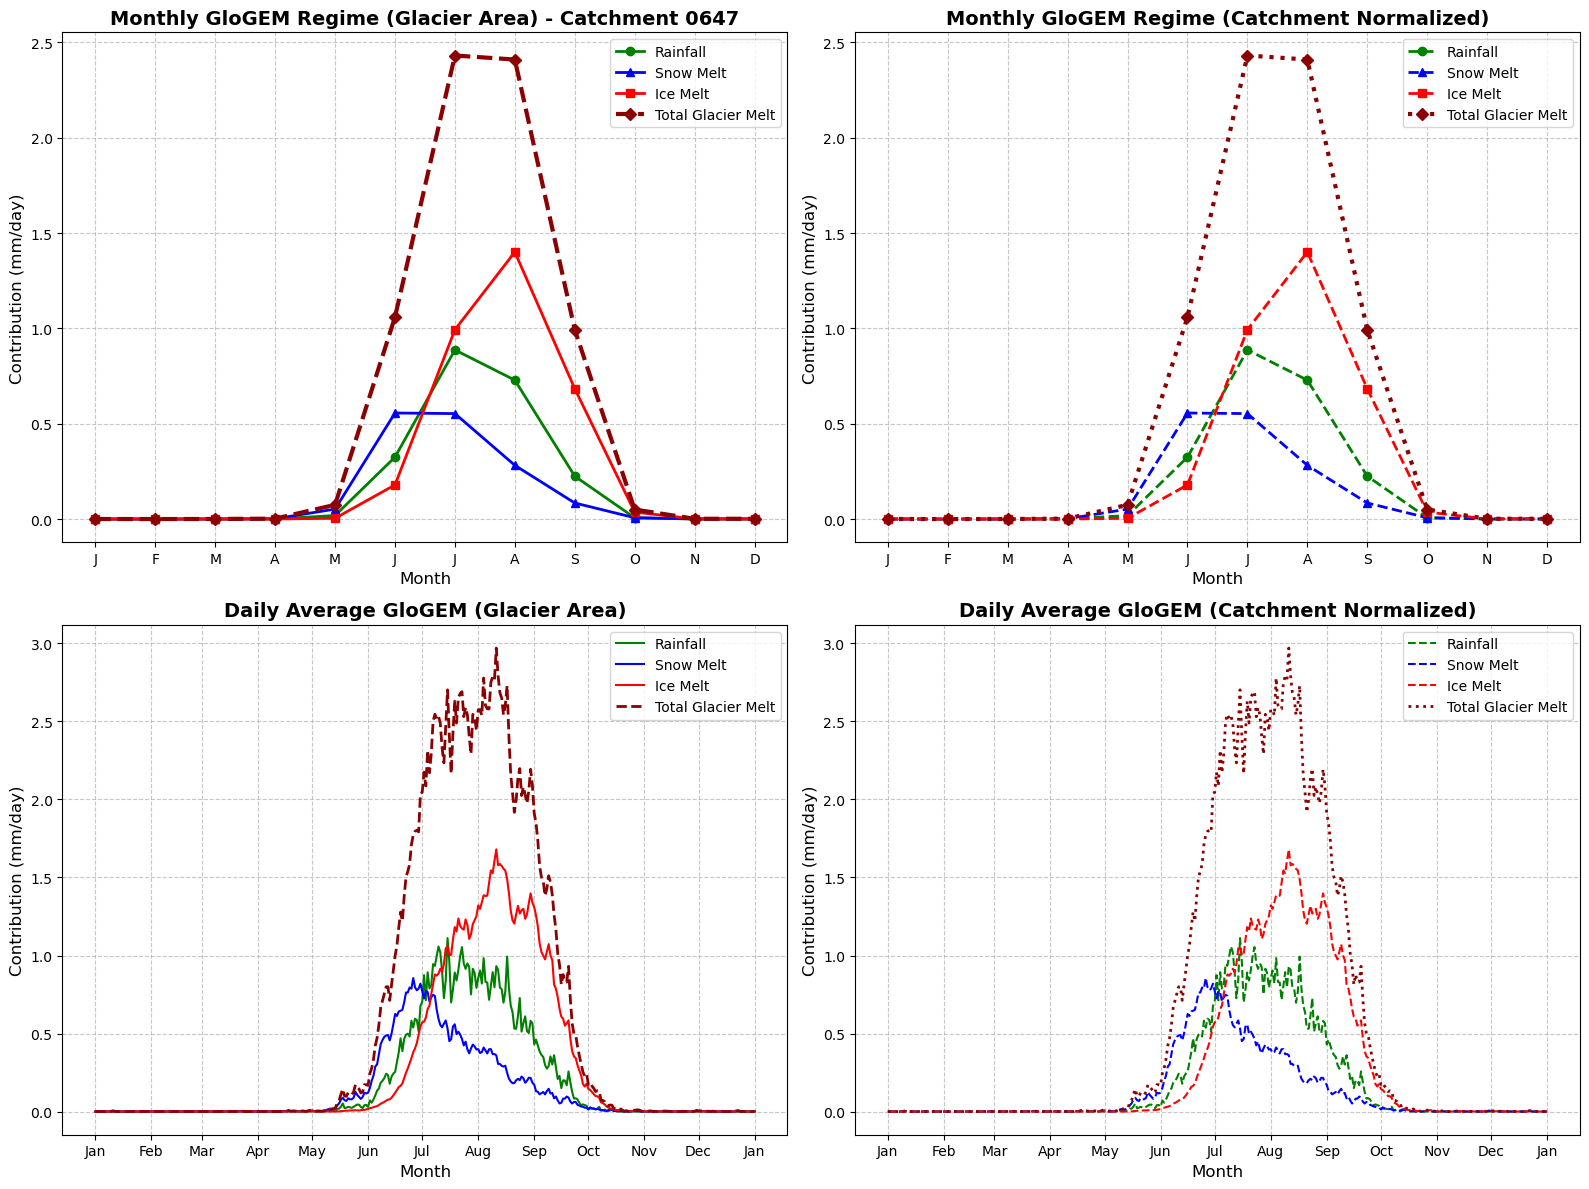


GloGEM Analysis Summary for Catchment 0647:
  Period: 2002-01-01 to 2019-12-31

  Annual averages (glacier area):
    Rainfall: 67.3 mm/year
    Snow melt: 47.0 mm/year
    Ice melt: 101.2 mm/year
    Total glacier melt: 215.5 mm/year

  Annual averages (catchment normalized):
    Rainfall: 67.3 mm/year
    Snow melt: 47.0 mm/year
    Ice melt: 101.2 mm/year
    Total glacier melt: 215.5 mm/year
   ✓ GloGEM regime plot created


In [9]:
# Cell 17: Test Contributions Functions
print("\n" + "=" * 60)
print("TESTING CONTRIBUTIONS FUNCTIONS")
print("=" * 60)

# If coupled mode
if config.get('coupled', False):
    print("\n1. Loading GloGEM data...")
    glogem_data = load_glogem_data(config, unit='mm', plot=False)
    
    if glogem_data is not None:
        print(f"   ✓ Loaded GloGEM data: {len(glogem_data)} records")
        
    print("\n2. GloGEM regime plot...")
    glogem_plot = plot_glogem_regime(config, plot_dirs)
    if glogem_plot is not None:
        print("   ✓ GloGEM regime plot created")

In [11]:
# Cell 18: Test Snowmelt Mass Loadings Functions
print("\n" + "=" * 60)
print("TESTING SNOWMELT MASS LOADINGS FUNCTIONS")
print("=" * 60)

print("\n1. Loading snowmelt mass loadings data...")
snowmelt_df = load_snowmelt_mass_loadings(config)

if snowmelt_df is not None:
    print(f"   ✓ Loaded snowmelt data: {len(snowmelt_df)} records")
    print(f"   Columns: {snowmelt_df.columns.tolist()}")
    print(f"   Date range: {snowmelt_df['date'].min()} to {snowmelt_df['date'].max()}")
    print(f"   Mean snowmelt: {snowmelt_df['snowmelt_m3s'].mean():.6f} m³/s")
    print(f"   Max snowmelt: {snowmelt_df['snowmelt_m3s'].max():.6f} m³/s")
    print(f"   Total snowmelt: {snowmelt_df['snowmelt_m3s'].sum():.2f} m³/s·days")
else:
    print("   ✗ Failed to load snowmelt mass loadings data")


TESTING SNOWMELT MASS LOADINGS FUNCTIONS

1. Loading snowmelt mass loadings data...
Loading snowmelt mass loadings for catchment 0647:
  - Period: 2011-12-31 to 2019-12-31
  - Loaded mass loadings: (6574, 4)
  - Columns: ['time[d]', 'date', 'hour', '0647 m3/s']
  - Successfully loaded snowmelt data (already in m³/s)
  - Date range: 2002-01-01 00:00:00 to 2019-12-31 00:00:00
  - Filtered to 2923 records
  - Zero snowmelt days: 966
  - Non-zero snowmelt days: 1957
  - Mean snowmelt: 14.9098 m³/s
  - Max snowmelt: 228.5020 m³/s
  - Sample values (first 5 days):
      2011-12-31: 0.0027 m³/s
      2012-01-01: 0.0018 m³/s
      2012-01-02: 0.0000 m³/s (no snowmelt)
      2012-01-03: 0.0000 m³/s (no snowmelt)
      2012-01-04: 0.0000 m³/s (no snowmelt)
  - Final valid records: 2923
   ✓ Loaded snowmelt data: 2923 records
   Columns: ['date', 'snowmelt_m3s']
   Date range: 2011-12-31 00:00:00 to 2019-12-31 00:00:00
   Mean snowmelt: 14.909787 m³/s
   Max snowmelt: 228.502000 m³/s
   Total sn

Loading snowmelt mass loadings for catchment 0647:
  - Period: 2011-12-31 to 2019-12-31
  - Loaded mass loadings: (6574, 4)
  - Columns: ['time[d]', 'date', 'hour', '0647 m3/s']
  - Successfully loaded snowmelt data (already in m³/s)
  - Date range: 2002-01-01 00:00:00 to 2019-12-31 00:00:00
  - Filtered to 2923 records
  - Zero snowmelt days: 966
  - Non-zero snowmelt days: 1957
  - Mean snowmelt: 14.9098 m³/s
  - Max snowmelt: 228.5020 m³/s
  - Sample values (first 5 days):
      2011-12-31: 0.0027 m³/s
      2012-01-01: 0.0018 m³/s
      2012-01-02: 0.0000 m³/s (no snowmelt)
      2012-01-03: 0.0000 m³/s (no snowmelt)
      2012-01-04: 0.0000 m³/s (no snowmelt)
  - Final valid records: 2923
Saved snowmelt time series plot to: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/HBV/output/plots/contributions/snowmelt_mass_loadings_timeseries_0647.png


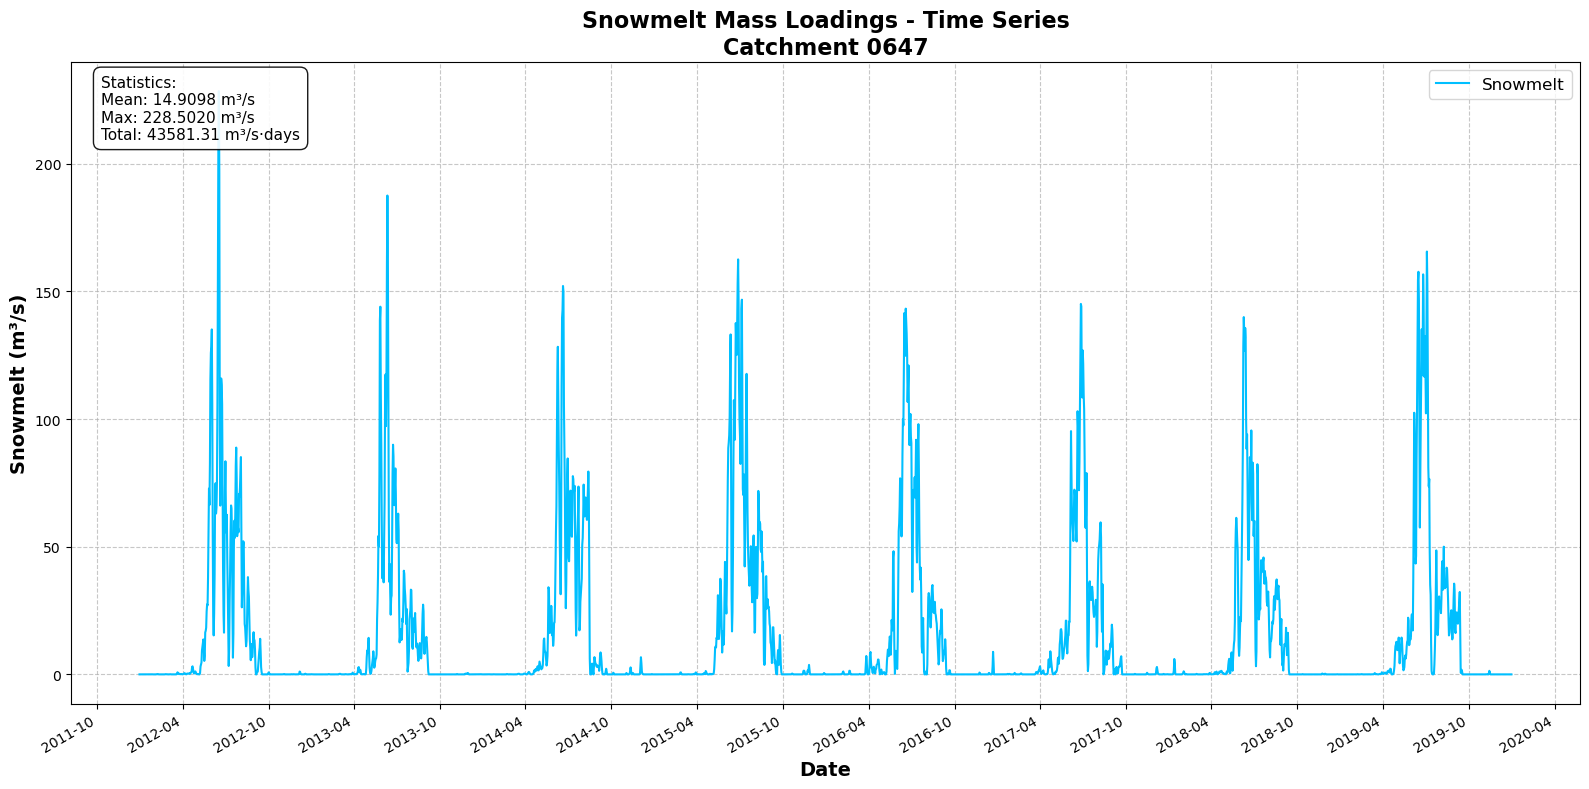


Snowmelt Mass Loadings Time Series Summary for Catchment 0647:
  Period: 2011-12-31 to 2019-12-31
  Mean snowmelt: 14.9098 m³/s
  Max snowmelt: 228.5020 m³/s
  Total snowmelt: 43581.31 m³/s·days


In [5]:
snowmelt_df = plot_snowmelt_timeseries(config,plot_dirs)


2. Snowmelt mass loadings regime plot...
Loading snowmelt mass loadings for catchment 0647:
  - Period: 2011-12-31 to 2019-12-31
  - Loaded mass loadings: (6574, 4)
  - Columns: ['time[d]', 'date', 'hour', '0647 m3/s']
  - Successfully loaded snowmelt data (already in m³/s)
  - Date range: 2002-01-01 00:00:00 to 2019-12-31 00:00:00
  - Filtered to 2923 records
  - Zero snowmelt days: 966
  - Non-zero snowmelt days: 1957
  - Mean snowmelt: 14.9098 m³/s
  - Max snowmelt: 228.5020 m³/s
  - Sample values (first 5 days):
      2011-12-31: 0.0027 m³/s
      2012-01-01: 0.0018 m³/s
      2012-01-02: 0.0000 m³/s (no snowmelt)
      2012-01-03: 0.0000 m³/s (no snowmelt)
      2012-01-04: 0.0000 m³/s (no snowmelt)
  - Final valid records: 2923
Saved snowmelt regime plot to: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/HBV/output/plots/contributions/snowmelt_mass_loadings_regime_0647.png


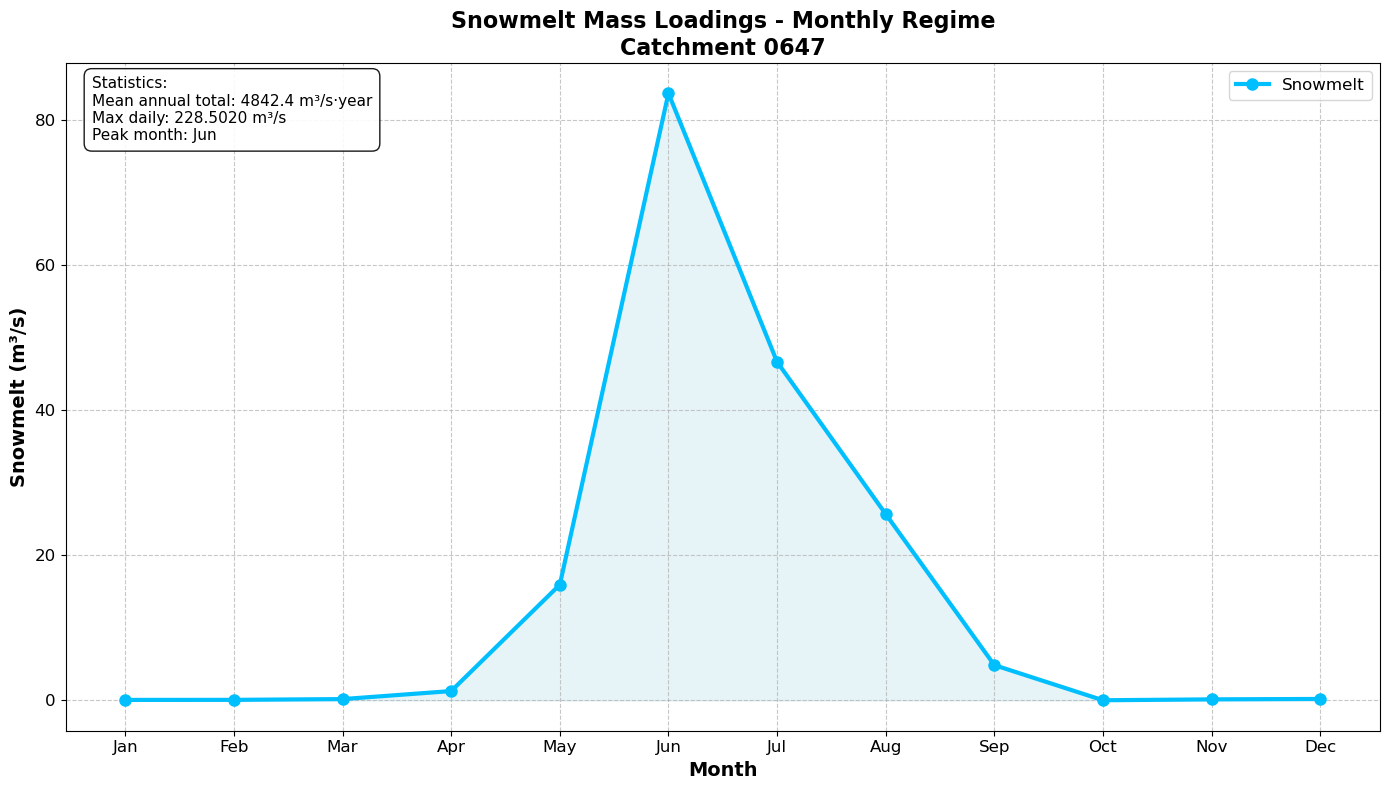


Snowmelt Mass Loadings Summary for Catchment 0647:
  Period: 2011-12-31 to 2019-12-31
  Mean annual snowmelt: 4842.4 m³/s·year
  Max daily snowmelt: 228.5020 m³/s
  Peak month: Jun (83.6260 m³/s)
  Min month: Oct (0.0147 m³/s)

Seasonal distribution:
  Winter (Dec-Feb): 0.1093 m³/s
  Spring (Mar-May): 5.7970 m³/s
  Summer (Jun-Aug): 51.9698 m³/s
  Fall (Sep-Nov): 1.6693 m³/s
   ✓ Snowmelt regime plot created
   Peak snowmelt month: 6
   Peak snowmelt value: 83.625959 m³/s

   Monthly regime values:
     Jan: 0.062405 m³/s
     Feb: 0.070361 m³/s
     Mar: 0.175105 m³/s
     Apr: 1.282567 m³/s
     May: 15.933458 m³/s
     Jun: 83.625959 m³/s
     Jul: 46.626574 m³/s
     Aug: 25.657001 m³/s
     Sep: 4.855056 m³/s
     Oct: 0.014664 m³/s
     Nov: 0.138167 m³/s
     Dec: 0.195267 m³/s


In [6]:
# Cell 19: Snowmelt Regime Plot
print("\n2. Snowmelt mass loadings regime plot...")
monthly_regime = plot_snowmelt_regime(config, plot_dirs)

if monthly_regime is not None:
    print("   ✓ Snowmelt regime plot created")
    print(f"   Peak snowmelt month: {monthly_regime.idxmax()}")
    print(f"   Peak snowmelt value: {monthly_regime.max():.6f} m³/s")
    print(f"\n   Monthly regime values:")
    for month, value in monthly_regime.items():
        month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
        print(f"     {month_names[month-1]}: {value:.6f} m³/s")
else:
    print("   ✗ Failed to create snowmelt regime plot")

In [6]:
# Cell 19.5: Test Glacier Melt Mass Loadings Functions
print("\n" + "=" * 60)
print("TESTING GLACIER MELT MASS LOADINGS FUNCTIONS")
print("=" * 60)

print("\n1. Loading glacier melt mass loadings data...")
glacier_data = load_glacier_melt_mass_loadings(config)

if glacier_data is not None:
    for glacier_type, df in glacier_data.items():
        if df is not None:
            print(f"\n   ✓ Loaded {glacier_type.upper()} glacier data: {len(df)} records")
            print(f"     Date range: {df['date'].min()} to {df['date'].max()}")
            print(f"     Mean glacier melt: {df['glacier_melt_m3s'].mean():.6f} m³/s")
            print(f"     Max glacier melt: {df['glacier_melt_m3s'].max():.6f} m³/s")
            print(f"     Total glacier melt: {df['glacier_melt_m3s'].sum():.2f} m³/s·days")
        else:
            print(f"   ✗ Failed to load {glacier_type.upper()} glacier data")
else:
    print("   ✗ Failed to load glacier melt mass loadings data")


TESTING GLACIER MELT MASS LOADINGS FUNCTIONS

1. Loading glacier melt mass loadings data...
Loading glacier melt mass loadings for catchment 0647:
  - Period: 2011-12-31 to 2019-12-31
  - Loaded SMALL glacier data: (6574, 4)
    ✓ Filtered to 2923 records
    - Zero glacier melt days: 1589
    - Non-zero glacier melt days: 1334
    - Mean: 0.9907 m³/s
    - Max: 8.6304 m³/s
  - Loaded LARGE glacier data: (6574, 4)
    ✓ Filtered to 2923 records
    - Zero glacier melt days: 1396
    - Non-zero glacier melt days: 1527
    - Mean: 2.3293 m³/s
    - Max: 18.9499 m³/s
  - Loaded ALL glacier data: (6574, 4)
    ✓ Filtered to 2923 records
    - Zero glacier melt days: 1396
    - Non-zero glacier melt days: 1527
    - Mean: 3.3200 m³/s
    - Max: 26.8046 m³/s
  ✓ Successfully loaded 3/3 glacier melt datasets

   ✓ Loaded SMALL glacier data: 2923 records
     Date range: 2011-12-31 00:00:00 to 2019-12-31 00:00:00
     Mean glacier melt: 0.990688 m³/s
     Max glacier melt: 8.630410 m³/s
     


2. Glacier melt mass loadings time series plot...
Loading glacier melt mass loadings for catchment 0647:
  - Period: 2011-12-31 to 2019-12-31
  - Loaded SMALL glacier data: (6574, 4)
    ✓ Filtered to 2923 records
    - Zero glacier melt days: 1589
    - Non-zero glacier melt days: 1334
    - Mean: 0.9907 m³/s
    - Max: 8.6304 m³/s
  - Loaded LARGE glacier data: (6574, 4)
    ✓ Filtered to 2923 records
    - Zero glacier melt days: 1396
    - Non-zero glacier melt days: 1527
    - Mean: 2.3293 m³/s
    - Max: 18.9499 m³/s
  - Loaded ALL glacier data: (6574, 4)
    ✓ Filtered to 2923 records
    - Zero glacier melt days: 1396
    - Non-zero glacier melt days: 1527
    - Mean: 3.3200 m³/s
    - Max: 26.8046 m³/s
  ✓ Successfully loaded 3/3 glacier melt datasets
Saved glacier melt time series plot to: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/HBV/output/plots/contributions/glacier_melt_timeseries_0647.png


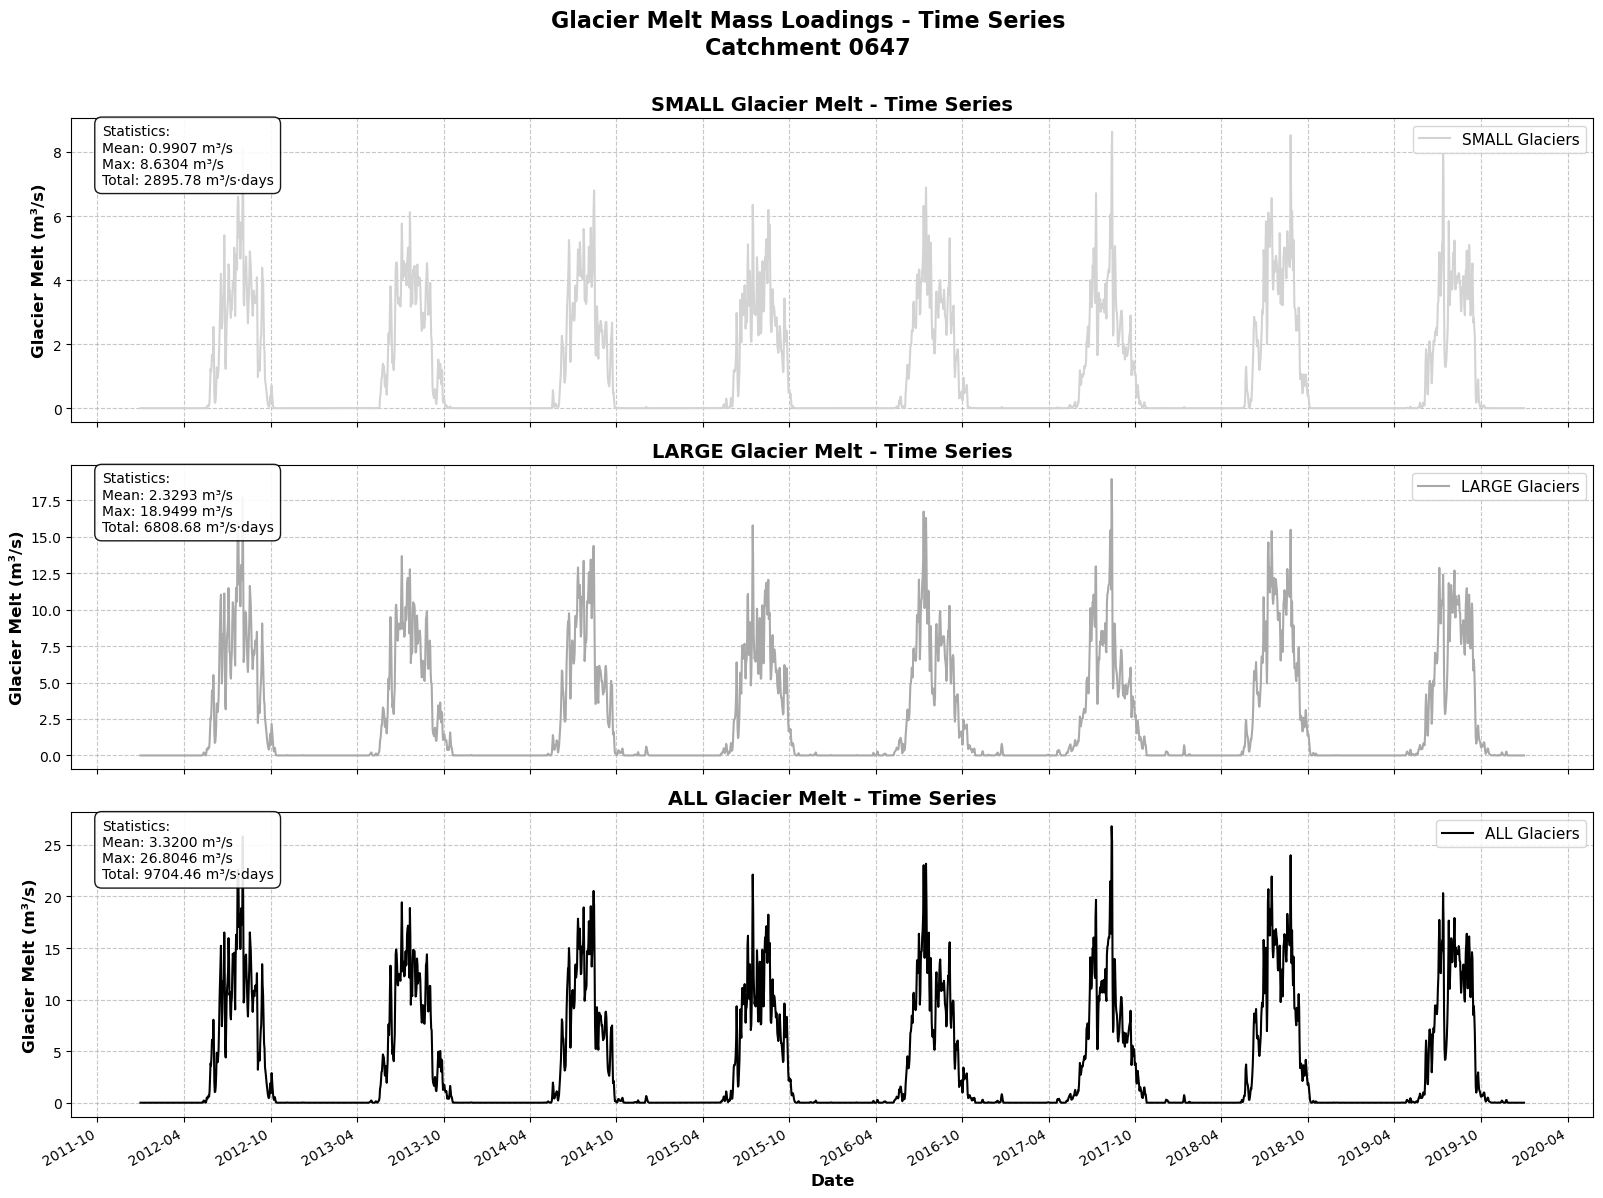

   ✓ Glacier melt time series plots created
     SMALL: 2923 records
     LARGE: 2923 records
     ALL: 2923 records


In [7]:
# Cell 19.6: Glacier Melt Time Series Plot
print("\n2. Glacier melt mass loadings time series plot...")
glacier_ts_data = plot_glacier_melt_timeseries(config, plot_dirs)

if glacier_ts_data is not None:
    print("   ✓ Glacier melt time series plots created")
    for glacier_type, df in glacier_ts_data.items():
        if df is not None:
            print(f"     {glacier_type.upper()}: {len(df)} records")
else:
    print("   ✗ Failed to create glacier melt time series plots")


3. Glacier melt mass loadings regime plot...
Loading glacier melt mass loadings for catchment 0647:
  - Period: 2011-12-31 to 2019-12-31
  - Loaded SMALL glacier data: (6574, 4)
    ✓ Filtered to 2923 records
    - Zero glacier melt days: 1589
    - Non-zero glacier melt days: 1334
    - Mean: 0.9907 m³/s
    - Max: 8.6304 m³/s
  - Loaded LARGE glacier data: (6574, 4)
    ✓ Filtered to 2923 records
    - Zero glacier melt days: 1396
    - Non-zero glacier melt days: 1527
    - Mean: 2.3293 m³/s
    - Max: 18.9499 m³/s
  - Loaded ALL glacier data: (6574, 4)
    ✓ Filtered to 2923 records
    - Zero glacier melt days: 1396
    - Non-zero glacier melt days: 1527
    - Mean: 3.3200 m³/s
    - Max: 26.8046 m³/s
  ✓ Successfully loaded 3/3 glacier melt datasets
Saved glacier melt regime plot to: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/HBV/output/plots/contributions/glacier_melt_regime_0647.png


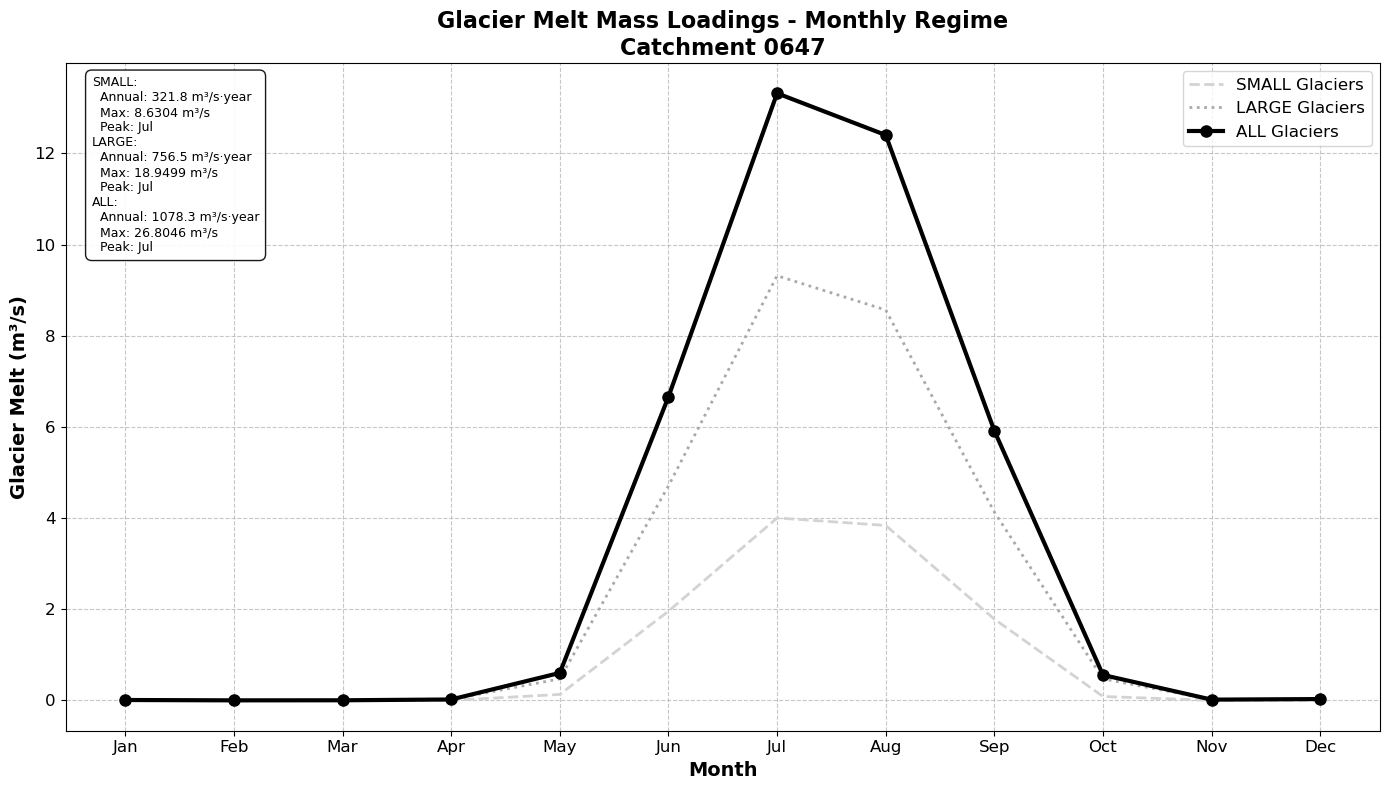


Glacier Melt Mass Loadings Summary for Catchment 0647:
  Period: 2011-12-31 to 2019-12-31

  SMALL Glaciers:
    Mean annual glacier melt: 321.8 m³/s·year
    Max daily glacier melt: 8.6304 m³/s
    Peak month: Jul (4.0029 m³/s)
    Min month: Feb (0.0000 m³/s)
    Seasonal distribution:
      Winter (Dec-Feb): 0.0003 m³/s
      Spring (Mar-May): 0.0435 m³/s
      Summer (Jun-Aug): 3.2657 m³/s
      Fall (Sep-Nov): 0.6229 m³/s

  LARGE Glaciers:
    Mean annual glacier melt: 756.5 m³/s·year
    Max daily glacier melt: 18.9499 m³/s
    Peak month: Jul (9.3183 m³/s)
    Min month: Feb (0.0003 m³/s)
    Seasonal distribution:
      Winter (Dec-Feb): 0.0121 m³/s
      Spring (Mar-May): 0.1645 m³/s
      Summer (Jun-Aug): 7.5301 m³/s
      Fall (Sep-Nov): 1.5401 m³/s

  ALL Glaciers:
    Mean annual glacier melt: 1078.3 m³/s·year
    Max daily glacier melt: 26.8046 m³/s
    Peak month: Jul (13.3212 m³/s)
    Min month: Feb (0.0003 m³/s)
    Seasonal distribution:
      Winter (Dec-Feb): 0.

In [8]:
# Cell 19.7: Glacier Melt Regime Plot
print("\n3. Glacier melt mass loadings regime plot...")
glacier_monthly_regimes = plot_glacier_melt_regime(config, plot_dirs)

if glacier_monthly_regimes is not None:
    print("   ✓ Glacier melt regime plot created")
    
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    for glacier_type, monthly_regime in glacier_monthly_regimes.items():
        print(f"\n   {glacier_type.upper()} Glacier:")
        print(f"     Peak month: {month_names[monthly_regime.idxmax()-1]}")
        print(f"     Peak value: {monthly_regime.max():.6f} m³/s")
        print(f"     Min month: {month_names[monthly_regime.idxmin()-1]}")
        print(f"     Min value: {monthly_regime.min():.6f} m³/s")
        
        print(f"\n     Monthly regime values:")
        for month, value in monthly_regime.items():
            print(f"       {month_names[month-1]}: {value:.6f} m³/s")
else:
    print("   ✗ Failed to create glacier melt regime plot")

Creating streamflow regime with all glacier melt and snowmelt for catchment 0647:
  - Period: 2011-12-31 to 2019-12-31
Loading hydrograph data:
  - File: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/HBV/output/0647_HBV_Hydrographs.csv
  - Found columns: sim=0647 [m3/s], obs=0647 (observed) [m3/s], precip=precip [mm/day]
  - Data range: 2002-01-02 00:00:00 to 2019-12-31 00:00:00
Loading snowmelt mass loadings for catchment 0647:
  - Period: 2011-12-31 to 2019-12-31
  - Loaded mass loadings: (6574, 4)
  - Columns: ['time[d]', 'date', 'hour', '0647 m3/s']
  - Successfully loaded snowmelt data (already in m³/s)
  - Date range: 2002-01-01 00:00:00 to 2019-12-31 00:00:00
  - Filtered to 2923 records
  - Zero snowmelt days: 0
  - Non-zero snowmelt days: 2923
  - Mean snowmelt: 24.9876 m³/s
  - Max snowmelt: 189.0200 m³/s
  - Sample values (first 5 days):
      2011-12-31: 0.0247 m³/s
      2012-01-01: 0.0513 m³/s
      2012-01-02: 0.0418 m³/s
      2012-01-03: 0

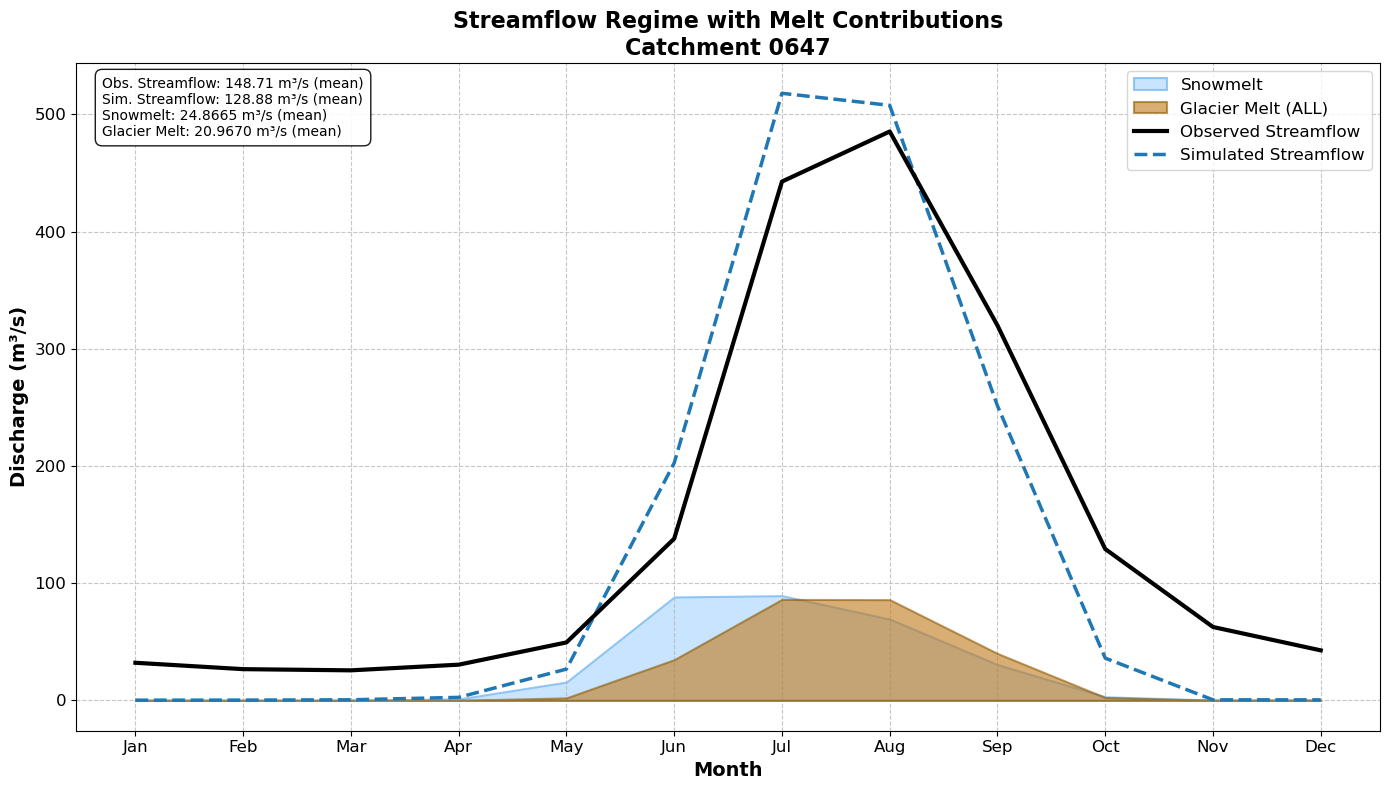

In [8]:
# Plot 1: With total glacier melt
regime_all = plot_streamflow_with_all_glacier_snowmelt_regime(config, plot_dirs)

Creating streamflow regime with separated glacier melt and snowmelt for catchment 0647:
  - Period: 2011-12-31 to 2019-12-31
Loading hydrograph data:
  - File: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/HBV/output/0647_HBV_Hydrographs.csv
  - Found columns: sim=0647 [m3/s], obs=0647 (observed) [m3/s], precip=precip [mm/day]
  - Data range: 2002-01-02 00:00:00 to 2019-12-31 00:00:00
Loading snowmelt mass loadings for catchment 0647:
  - Period: 2011-12-31 to 2019-12-31
  - Loaded mass loadings: (6574, 4)
  - Columns: ['time[d]', 'date', 'hour', '0647 m3/s']
  - Successfully loaded snowmelt data (already in m³/s)
  - Date range: 2002-01-01 00:00:00 to 2019-12-31 00:00:00
  - Filtered to 2923 records
  - Zero snowmelt days: 0
  - Non-zero snowmelt days: 2923
  - Mean snowmelt: 24.9876 m³/s
  - Max snowmelt: 189.0200 m³/s
  - Sample values (first 5 days):
      2011-12-31: 0.0247 m³/s
      2012-01-01: 0.0513 m³/s
      2012-01-02: 0.0418 m³/s
      2012-01

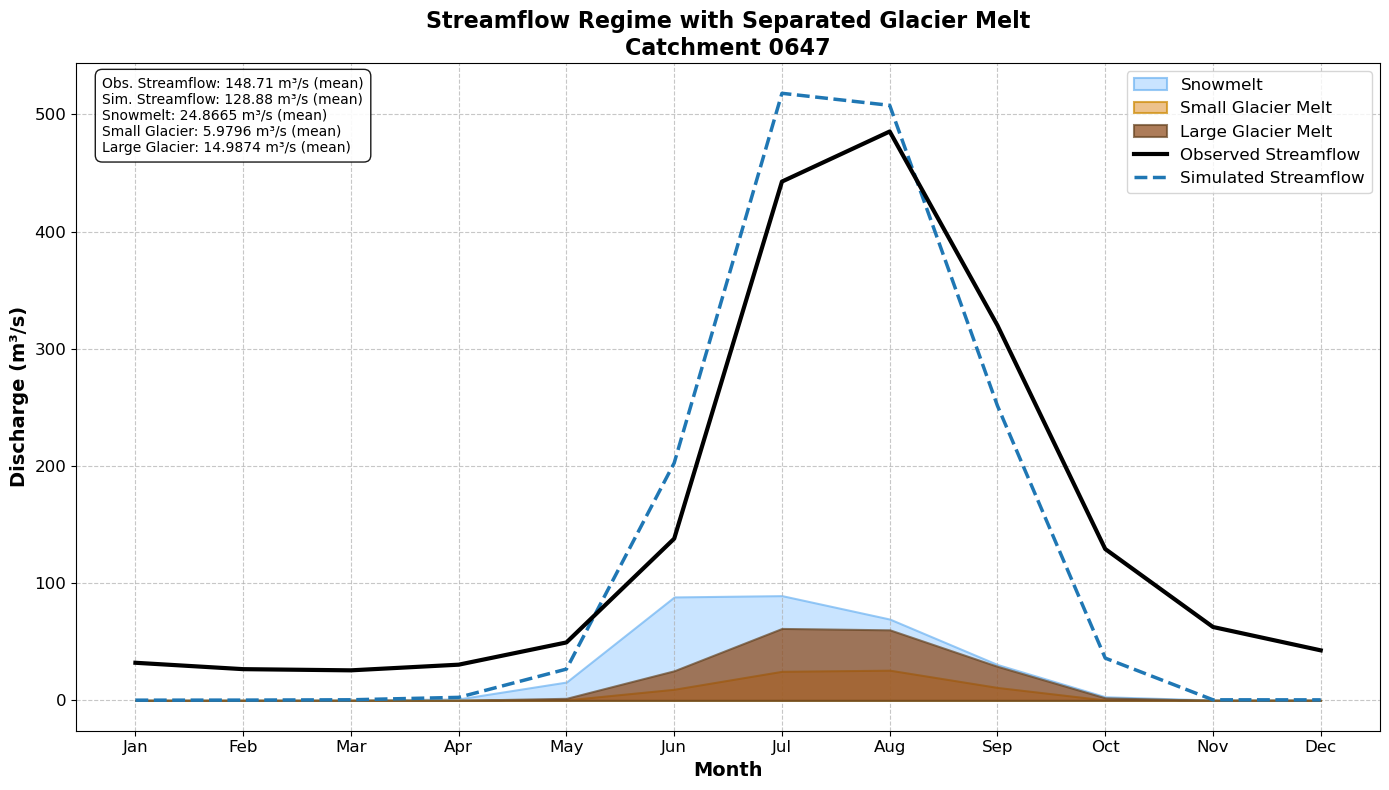


Streamflow Regime Summary:
  Period: 2011-12-31 to 2019-12-31
  Observed streamflow: 148.71 m³/s (mean)
    Peak: Aug (485.37 m³/s)
  Simulated streamflow: 128.88 m³/s (mean)
    Peak: Jul (517.96 m³/s)
  Snowmelt: 24.8665 m³/s (mean)
    Peak: Jul (89.3419 m³/s)
  Small glacier melt: 5.9796 m³/s (mean)
    Peak: Aug (25.7545 m³/s)
  Large glacier melt: 14.9874 m³/s (mean)
    Peak: Jul (61.3640 m³/s)


In [9]:
regime_separated = plot_streamflow_with_separated_glacier_snowmelt_regime(config, plot_dirs)

In [4]:
# Load rainfall data
rainfall_df = load_rainfall_mass_loadings(config)

if rainfall_df is not None:
    print(f"Loaded {len(rainfall_df)} days of rainfall data")
    print(f"Mean daily rainfall: {rainfall_df['rainfall_mm_day'].mean():.2f} mm/day")

Loading rainfall mass loadings for catchment 0647:
  - Period: 2011-12-31 to 2019-12-31
  - Catchment area: 2930.40 km²
  - Conversion factor (m³/s to mm/day): 0.029484
  - Loaded mass loadings: (6574, 4)
  - Columns: ['time[d]', 'date', 'hour', '0647 m3/s']
  - Successfully loaded and converted rainfall data
  - Date range: 2002-01-01 00:00:00 to 2019-12-31 00:00:00
  - Filtered to 2923 records
  - Zero rainfall days: 0
  - Non-zero rainfall days: 2923
  - Mean rainfall: 2.5788 mm/day
  - Max rainfall: 28.0713 mm/day
  - Sample values (first 5 days):
      2011-12-31: 0.0000 mm/day
      2012-01-01: 0.0000 mm/day
      2012-01-02: 0.0101 mm/day
      2012-01-03: 0.0166 mm/day
      2012-01-04: 0.0027 mm/day
  - Final valid records: 2923
Loaded 2923 days of rainfall data
Mean daily rainfall: 2.58 mm/day



COMPREHENSIVE ANNUAL WATER BALANCE ANALYSIS
Catchment: 0647
Period: 2011-12-31 to 2019-12-31
Coupled mode: True

1. Catchment area: 2930.40 km²
   Conversion factor (m³/s to mm/day): 0.029484

2. Loading streamflow data...
Loading hydrograph data:
  - File: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/HBV/output/0647_HBV_Hydrographs.csv
  - Found columns: sim=0647 [m3/s], obs=0647 (observed) [m3/s], precip=precip [mm/day]
  - Data range: 2002-01-02 00:00:00 to 2019-12-31 00:00:00
   ✓ Loaded streamflow data: 9 years
     Mean annual observed streamflow: 1414.8 mm/year
     Mean annual simulated streamflow: 1244.5 mm/year

3. Loading GloGEM data...
Loading catchment-averaged GloGEM data for catchment 0647:
  - File: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/topo_files/GloGEM_catchment_averaged.csv
  - Period: 2002-01-01 to 2019-12-31
  - Loaded 6570 records
  - Columns: ['date', 'icemelt_glacier_area', 'icemelt_catchment_

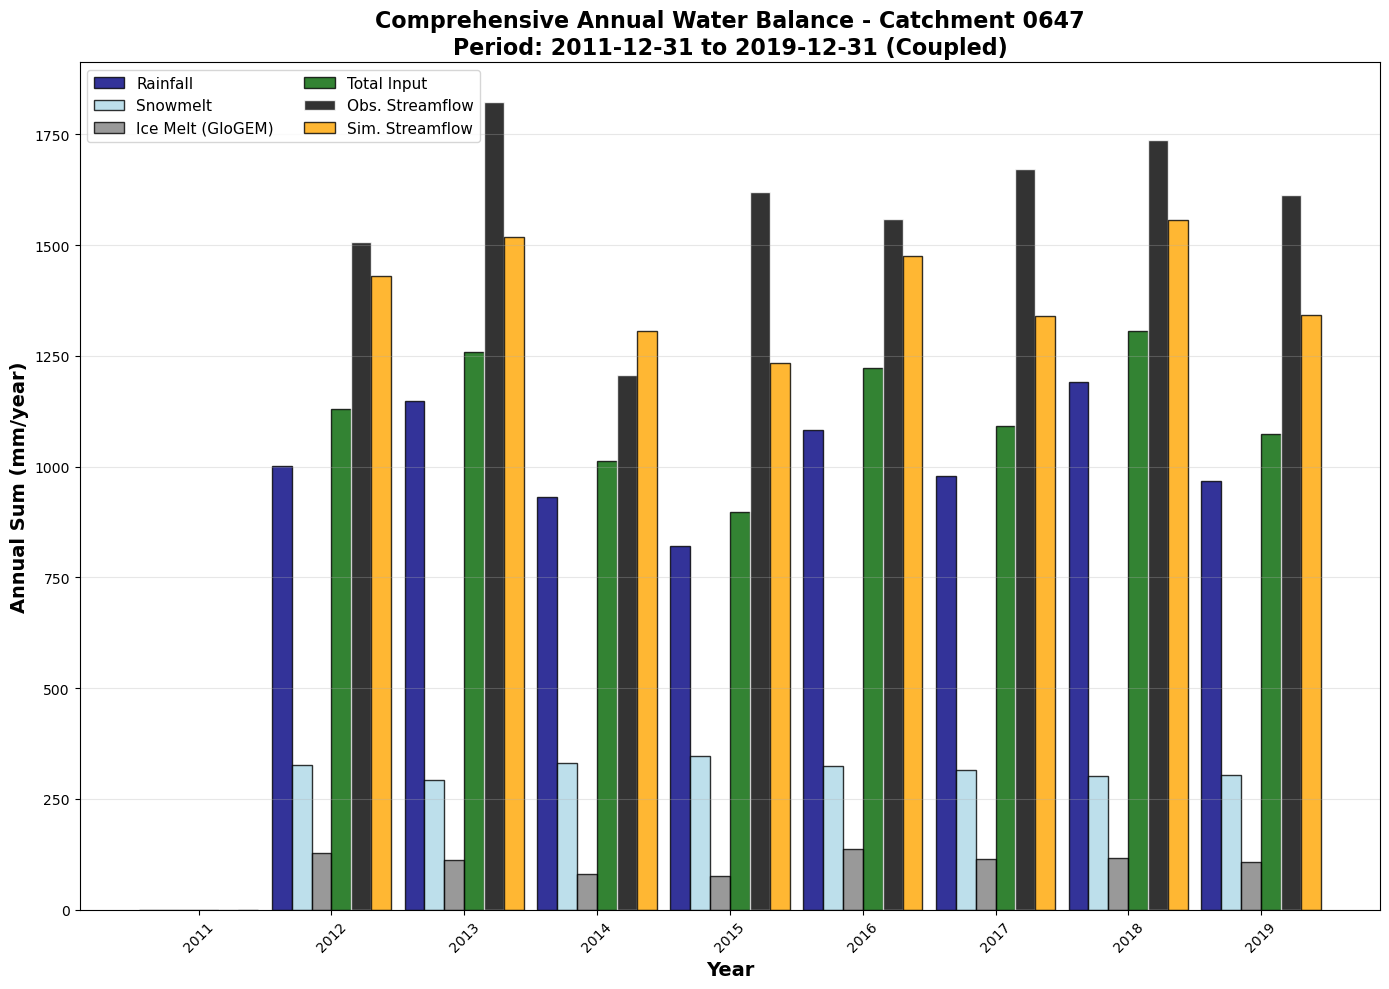


9. Creating stacked area plot...
   ✓ Saved stacked area plot to: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/HBV/output/plots/contributions/comprehensive_annual_water_balance_stacked_0647.png


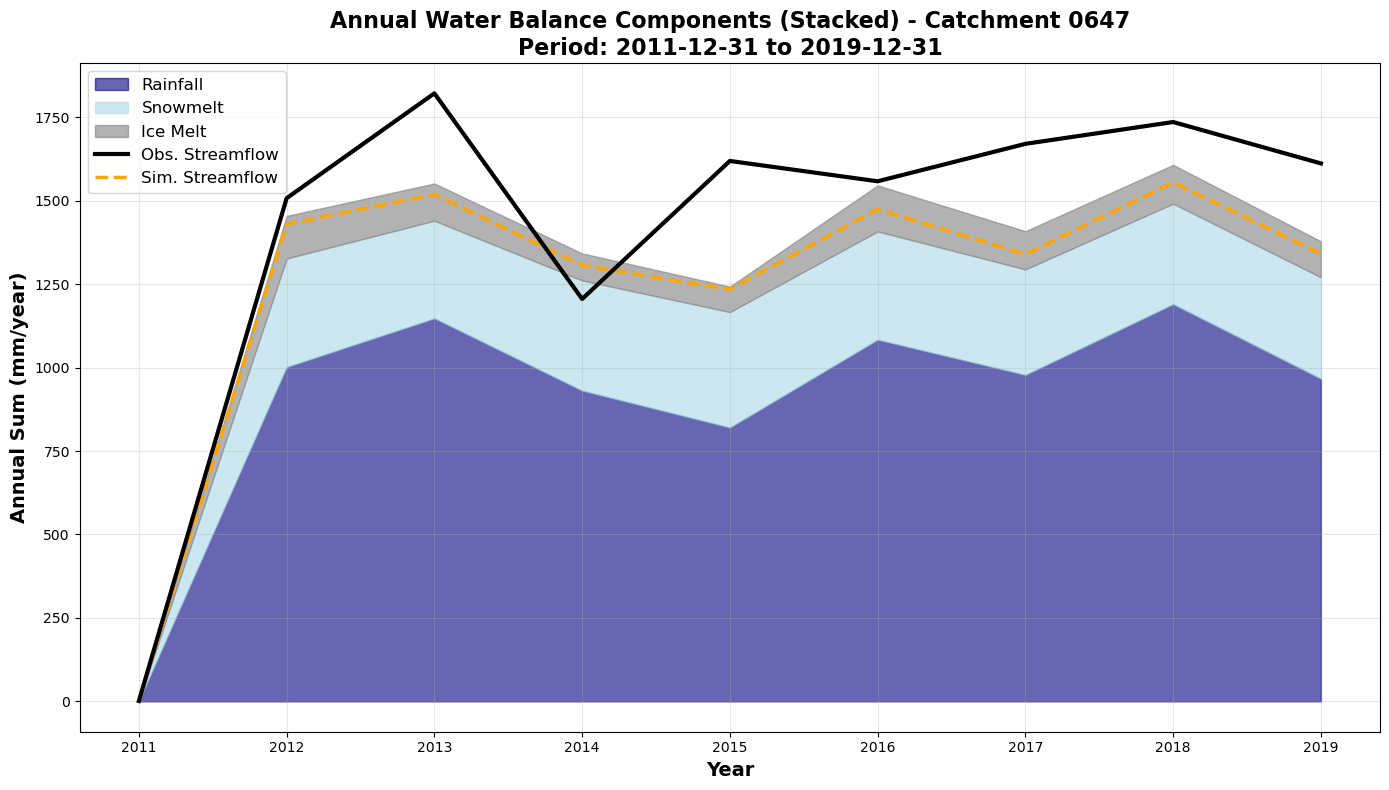


10. Creating water balance ratio plot...
   ✓ Saved ratio plot to: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/HBV/output/plots/contributions/comprehensive_annual_water_balance_ratios_0647.png


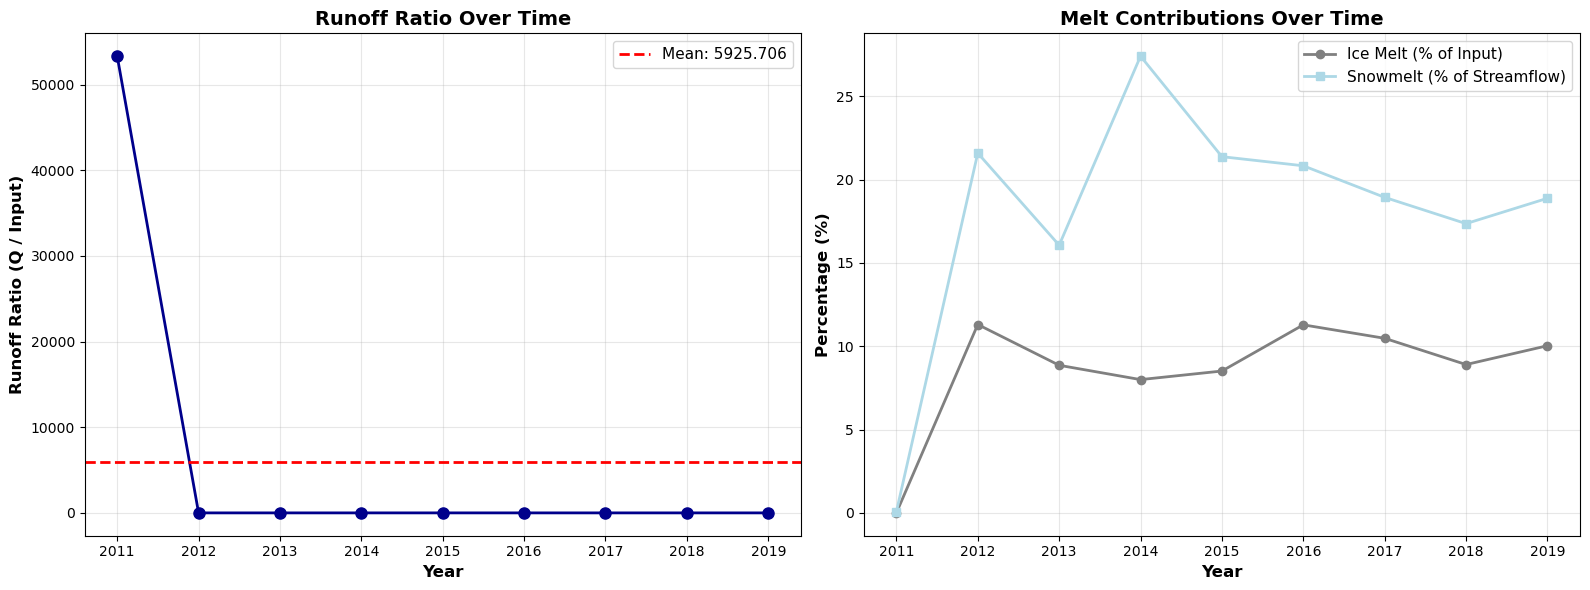


11. Saving data to CSV...
   ✓ Saved data to: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/HBV/results/comprehensive_annual_water_balance_0647.csv

SUMMARY STATISTICS
Period: 2011 - 2019
Number of years: 9

Mean annual values (mm/year):
  Rainfall (total): 902.0 ± 356.6
    - GloGEM: 64.5
    - HBV: 837.5
  Snowmelt (total): 282.5 ± 107.2
    - GloGEM: 43.2
    - HBV: 239.3
  Ice melt (GloGEM): 97.0 ± 41.4
  Total input: 999.0 ± 395.5
  Observed streamflow: 1414.8 ± 557.6
  Simulated streamflow: 1244.5 ± 478.3

Mean ratios:
  Runoff ratio: 5925.706 ± 17772.838
  Ice melt / Input: 8.6%
  Snowmelt / Streamflow: 18.1%

COMPREHENSIVE WATER BALANCE ANALYSIS COMPLETE



In [5]:
annual_balance_df = plot_comprehensive_annual_water_balance(config, plot_dirs)

Creating GloGEM vs Observed Streamflow regime for catchment 0647:
  - Period: 2011-12-31 to 2019-12-31
Loading catchment-averaged GloGEM data for catchment 0647:
  - File: /home/jberg/OneDrive/Raven_worldwide/03_model_setups_coupled/catchment_0647/topo_files/GloGEM_catchment_averaged.csv
  - Period: 2002-01-01 to 2019-12-31
  - Loaded 6570 records
  - Columns: ['date', 'icemelt_glacier_area', 'icemelt_catchment_area', 'snowmelt_glacier_area', 'snowmelt_catchment_area', 'rain_glacier_area', 'rain_catchment_area', 'melt_glacier_area', 'melt_catchment_area']
  ✓ Successfully loaded catchment-averaged GloGEM data
  - Date range: 2002-01-01 00:00:00 to 2019-12-31 00:00:00

  Mean values (glacier area):
    Ice melt: 0.277 mm/day
    Snow melt: 0.129 mm/day
    Rainfall: 0.184 mm/day
    Total melt: 0.590 mm/day

  Mean values (catchment area):
    Ice melt: 0.277 mm/day
    Snow melt: 0.129 mm/day
    Rainfall: 0.184 mm/day
    Total melt: 0.590 mm/day
  - GloGEM total output mean: 0.9549 m

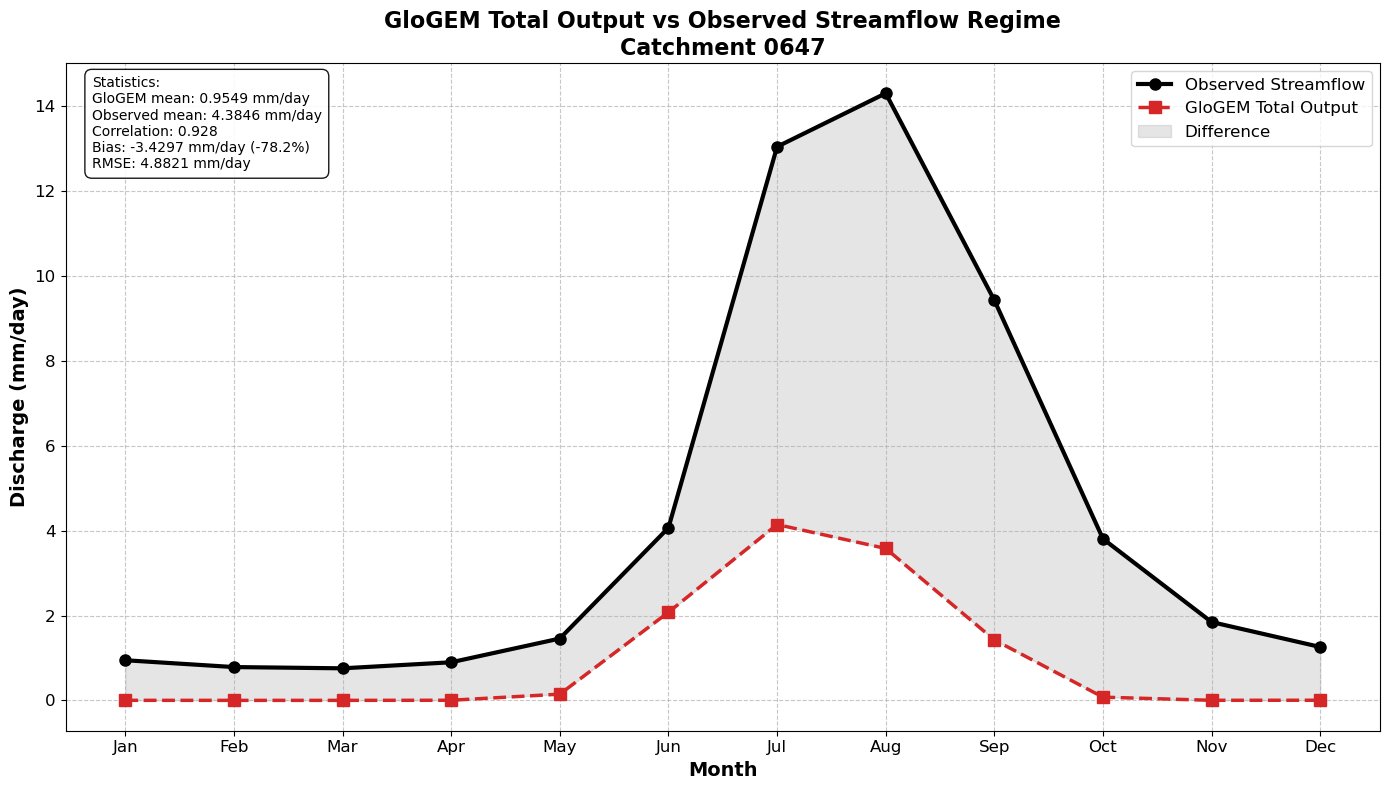


GloGEM vs Observed Streamflow Regime Summary:
  Period: 2011-12-31 to 2019-12-31
  GloGEM total output mean: 0.9549 mm/day
  Observed streamflow mean: 4.3846 mm/day
  Correlation: 0.928
  Mean bias: -3.4297 mm/day (-78.2%)
  RMSE: 4.8821 mm/day
  Peak month (GloGEM): Jul
  Peak month (Observed): Aug

Monthly Comparison:
  Jan: GloGEM=0.0010, Obs=0.9460, Diff=-0.9449 (-99.9%)
  Feb: GloGEM=0.0000, Obs=0.7851, Diff=-0.7851 (-100.0%)
  Mar: GloGEM=0.0002, Obs=0.7554, Diff=-0.7552 (-100.0%)
  Apr: GloGEM=0.0025, Obs=0.8979, Diff=-0.8955 (-99.7%)
  May: GloGEM=0.1466, Obs=1.4574, Diff=-1.3108 (-89.9%)
  Jun: GloGEM=2.0767, Obs=4.0683, Diff=-1.9916 (-49.0%)
  Jul: GloGEM=4.1449, Obs=13.0505, Diff=-8.9055 (-68.2%)
  Aug: GloGEM=3.5810, Obs=14.3106, Diff=-10.7296 (-75.0%)
  Sep: GloGEM=1.4251, Obs=9.4318, Diff=-8.0068 (-84.9%)
  Oct: GloGEM=0.0755, Obs=3.8078, Diff=-3.7323 (-98.0%)
  Nov: GloGEM=0.0015, Obs=1.8460, Diff=-1.8444 (-99.9%)
  Dec: GloGEM=0.0032, Obs=1.2581, Diff=-1.2549 (-99.7%)


In [4]:
glogem_vs_obs = plot_glogem_vs_observed_streamflow_regime(config, plot_dirs)

In [ ]:
# Cell 28: Test Uncertainty Functions (OPTIONAL - takes longer)
print("\n" + "=" * 60)
print("TESTING UNCERTAINTY FUNCTIONS (This may take several minutes)")
print("=" * 60)

# Only run if you have template directory and Raven executable
test_uncertainty = False  # Set to True to test

if test_uncertainty:
    print("\n1. Combined uncertainty analysis...")
    uncertainty_result = plot_combined_uncertainty_with_envelope(
        config, plot_dirs, n_runs=5  # Use fewer runs for testing
    )
    
    if uncertainty_result is not None:
        print("   ✓ Uncertainty analysis completed")
else:
    print("   Skipped (set test_uncertainty=True to run)")

In [ ]:
# Cell 29: Run Complete Postprocessing (ALL FUNCTIONS)
print("\n" + "=" * 60)
print("RUNNING COMPLETE POSTPROCESSING PIPELINE")
print("=" * 60)

# This runs everything in one go
complete_results = run_complete_postprocessing(config)

if complete_results:
    success_count = sum(1 for v in complete_results['success'].values() if v is True)
    total = len([v for v in complete_results['success'].values() if v is not None])
    print(f"\n✓ Complete postprocessing finished: {success_count}/{total} analyses successful")

In [ ]:
# Cell 30: Summary of Results
print("\n" + "=" * 60)
print("POSTPROCESSING TEST SUMMARY")
print("=" * 60)

if 'complete_results' in locals() and complete_results:
    print("\nSuccessful analyses:")
    for analysis, success in complete_results['success'].items():
        if success is True:
            print(f"  ✓ {analysis}")
    
    print("\nFailed analyses:")
    for analysis, error in complete_results['errors'].items():
        print(f"  ✗ {analysis}: {error}")
    
    print(f"\nPlot directories:")
    for key, path in plot_dirs.items():
        print(f"  {key}: {path}")
else:
    print("Run Cell 29 to see complete results summary")